In [1]:
#always run this first!!
#essential reticulate functions that allow us to use python packages in R
#you'll need a conda env with 'leidenalg' and 'pandas' installed to do this
#then route reticulate to the python installed in that conda env with the below functions
Sys.setenv(RETICULATE_PYTHON="/home/welison/.conda/envs/decontX_reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/welison/.conda/envs/decontX_reticulate/bin/python")
reticulate::use_condaenv("/home/welison/.conda/envs/decontX_reticulate")
reticulate::py_module_available(module='leidenalg') #needs to be TRUE
reticulate::import('leidenalg') #good to make sure this doesn't error

Warning message:
“package ‘reticulate’ was built under R version 4.3.3”


[1] TRUE

Module(leidenalg)

In [2]:
#is you get messages that any of these packages aren't installed
#go ahead and locally install them yourself using install.packages()

#library(GenomeInfoDb,lib.loc="/nfs/lab/welison/multiome_practice/lib/")

#suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
#install.packages('harmony')
suppressMessages(library(harmony))
suppressMessages(library(data.table))
#suppressMessages(library(ggpubr))
library(gridExtra)
warnLevel <- getOption('warn')
options(warn = -1)
library(BPCells)
library(stringr)
library(tidyr)
#library(ggh4x) # Luca's Dotplot code
library(presto)

library(GenomicRanges)
library(GenomeInfoDb)
library(anndata)

library(viridis)
library(future.apply)
library(dplyr)
library(broom)
library(pheatmap)
library(RColorBrewer)
library(mgcv)
library(qvalue)

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘ensembldb’ was built under R version 4.3.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘GenomicFeatures’ was built under R version 4.3.2”
Warning message:
“package ‘AnnotationDbi’ was built under R version 4.3.2”
Warning message:
“package ‘Biobase’ was built under R version 4.3.3”
Warning message:
“package ‘AnnotationFilter’ was built under R version 4.3.2”
Warning message:
"package 'dplyr' was built under R version 4

In [3]:
library(RhpcBLASctl)
RhpcBLASctl::blas_set_num_threads(24)

In [4]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS/LAPACK: /home/welison/.conda/envs/mamba/envs/seurat5.0_decontx/lib/libopenblasp-r0.3.21.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RhpcBLASctl_0.23-42       qvalue_2.34.0            
 [3] mgcv_1.9-1                nlme_3.1-164             
 [5] RColorBrewer_1.1-3        pheatmap_1.0.12          
 [7] broom_1.0.

In [6]:
adata <- readRDS('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/Hepatocytes_subtype_UnionPeaks_seurat_object.RDS')
adata 

An object of class Seurat 
986876 features across 233608 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [7]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "donor_demux"                       "nCount_SCT"                       
 [9] "nFeature_SCT"                      "SCT.weight"                       
[11] "seurat_clusters"                   "log_nCount_SCT"                   
[13] "log_nFeature_SCT"                  "lane"                             
[15] "batch"                             "gex_raw_reads"                    
[17] "gex_mapped_reads"                  "gex_conf_intergenic_reads"        
[19] "gex_conf_exonic_reads"             "gex_conf_intronic_reads"          
[21] "gex_conf_exonic_unique_reads"      "gex_conf_exonic_antisense_reads"  
[23] "gex_conf_exonic_dup_reads"         "gex_exonic_umis"                  
[25] "gex_conf_intronic_unique_reads"    "gex_conf_intronic_antisense_reads"
[27] "gex_conf_intronic_dup_reads"       "gex_intronic_umis"                
[29] "gex_conf_txomic_unique_reads"      "gex_umis_count"                   
[31] "gex_genes_count"                   "atac_raw_reads"                   
[33] "atac_unmapped_reads"               "atac_lowmapq"                     
[35] "atac_dup_reads"                    "atac_chimeric_reads"              
[37] "atac_mitochondrial_reads"          "atac_fragments"                   
[39] "atac_TSS_fragments"                "atac_peak_region_fragments"       
[41] "atac_peak_region_cutsites"         "TSS.enrichment"                   
[43] "TSS.percentile"                    "condition"                        
[45] "disease_status"                    "library"                          
[47] "amulet"                            "nCount_Peaks"                     
[49] "nFeature_Peaks"                    "Description"                      
[51] "Age"                               "BMI"                              
[53] "Gender"                            "Alcoholic..2..Drinks.Day."        
[55] "Steatosis.grade"                   "Steatosis.."                      
[57] "Fat.distribution"                  "Lobular.inflammation"             
[59] "Ballooning"                        "Portal.inflammation"              
[61] "Hepatocyte.necrosis"               "MASH.CRN.score..X.8"              
[63] "Diagnosis"                         "Peaks.weight"                     
[65] "value"                             "barcode"                          
[67] "cellsubtype"                       "celltype"                         
[69] "nCount_Peaks_Full"                 "nFeature_Peaks_Full"              
[71] "Fibrosis.stage"                    "nCount_Peaks.1"                   
[73] "nFeature_Peaks.1"                  "nCount_Peaks.2"                   
[75] "nFeature_Peaks.2"                  "nCount_Subtype.Peaks"             
[77] "nFeature_Subtype.Peaks"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



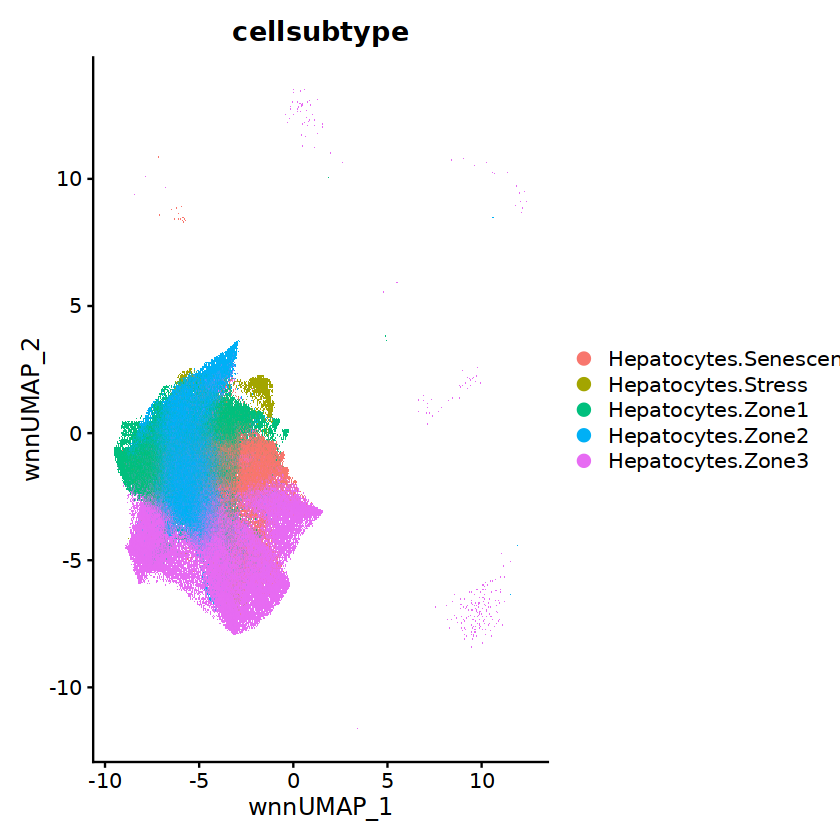

In [13]:
DimPlot(adata, reduction = 'umap.wnn', group.by = 'cellsubtype')

# Make consensus peaks

In [ ]:
#Bash

#First in bash to remove GIANT header
ls *.xls | sed 's/_peaks.xls//g' > listofcells.txt
mapfile -t cells < listofcells.txt
for cell in ${cells[@]}; do tail -n +22 ${cell}_peaks.xls > ${cell}.noheader.bed; done

In [5]:
#Now in R

##DO THIS OR IT WILL RANDOMLY PUT YOUR COORDINATES IN SCIENTIFIC NOTATION\n"
options(scipen=999)

In [6]:
#Read in peak lists
cells<-scan('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/listofcells.txt', sep="\n", what="")
orgpeaks<-list()
for (cell in cells){
    orgpeaks[[cell]]<-read.table(sprintf('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/%s.noheader.bed',cell), sep="\t", header=TRUE)
}
head(orgpeaks[[1]])

,chr,start,end,length,abs_summit,pileup,X.log10.pvalue.,fold_enrichment,X.log10.qvalue.,name
,<chr>,<int>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<chr>
1,chr1,9914,10684,771,10117,2703,2614.8600,23.91650,2611.5100,Hepatocytes.Senescent_peak_1
2,chr1,16091,16348,258,16197,193,35.4911,2.83826,33.7411,Hepatocytes.Senescent_peak_2
3,chr1,17344,17629,286,17508,273,78.7263,4.00868,76.8318,Hepatocytes.Senescent_peak_3
4,chr1,29217,29497,281,29347,271,77.5080,3.97942,75.6167,Hepatocytes.Senescent_peak_4
5,chr1,102694,103219,526,102939,1060,840.7540,15.52270,838.1090,Hepatocytes.Senescent_peak_5
6,chr1,136543,136981,439,136797,188,33.2104,2.76511,31.4713,Hepatocytes.Senescent_peak_6


In [7]:
for (cell in cells) {
    print(cell)
    print(dim(orgpeaks[[cell]]))
    print(dim(filter(orgpeaks[[cell]], X.log10.qvalue. > quantile(orgpeaks[[cell]]$X.log10.qvalue., .2))))
}

[1] "Hepatocytes.Senescent"
[1] 204909     10
[1] 163927     10
[1] "Hepatocytes.Stress"
[1] 135113     10
[1] 108089     10
[1] "Hepatocytes.Zone1"
[1] 208804     10
[1] 166622     10
[1] "Hepatocytes.Zone2"
[1] 248045     10
[1] 198436     10
[1] "Hepatocytes.Zone3"
[1] 230549     10
[1] 184439     10


In [8]:
#Shrink peaks greater than 300bp down to 300bp
shrunkpeaks<-lapply(1:length(cells), function(i){
    df<-orgpeaks[[i]]
    df[df$length>300,] <- df[df$length>300,] %>% mutate(start=abs_summit - 150,end=abs_summit + 150, length=300)
    print(dim(filter(df, start < 1)))
    df[df$start < 1,] <- df[df$start < 1,] %>% mutate(start=1) %>% mutate(length=end - start)
    df <- select(df, chr, start, end, length, pileup, everything())
    return(df)
})

[1]  0 10
[1]  0 10
[1]  0 10
[1]  0 10
[1]  0 10


In [9]:
#Make sure cell names match then add names back into list
##NOTE: Some of the string parsing here will dependon your naming convention! In this case, my string is Celltype_peak_#
for (i in 1:length(cells)){
    df<-shrunkpeaks[[i]]
    string<-df[1,10]
    ct<-sub("_.*", "", string)
    ctorder<-cells[i]
    message(paste0("Does ", ct, " match ", ctorder,"?"))
} 

Does Hepatocytes.Senescent match Hepatocytes.Senescent?

Does Hepatocytes.Stress match Hepatocytes.Stress?

Does Hepatocytes.Zone1 match Hepatocytes.Zone1?

Does Hepatocytes.Zone2 match Hepatocytes.Zone2?

Does Hepatocytes.Zone3 match Hepatocytes.Zone3?



In [10]:
#Add names back in (these get lost during lapply)
names(shrunkpeaks)<-cells

In [11]:
#Save peaks
for (i in 1:length(cells)){
    df<-shrunkpeaks[[i]]
    ct<-names(shrunkpeaks)[i]
    write.table(df, sprintf('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/%s.shrunkpeaks.bed',ct), row.names=FALSE, sep="\t", quote=FALSE)
}

In [ ]:
#Basically everything else is now bash
#Modify input to be ready for bedops

mapfile -t cells < listofcells.txt
#for cell in ${cells[@]}; do awk '{print $1,$2,$3,$10,$6}' OFS="\t" ${cell}.shrunkpeaks.bed | tail -n +2 > ${cell}.mod.shrunkpeaks.bed; done
for cell in ${cells[@]}; do tail -n +2 ${cell}.shrunkpeaks.bed > ${cell}.shrunkpeaks.noheader.bed; done
head -n 1 ${cells}.shrunkpeaks.bed > header

#!/bin/bash
##Define directory locations
#input directory must contain files with .bed extension to be analyzed
indir=/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/
tmpdir=/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/tmpdir/
outdir=/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/

#Name your output
outfile=LiverUnionPeaks.bed
#Initialize iteration, output and stop clause
touch ${outdir}/${outfile}
iters=1
stop=0

#Make tmp directory
if [ ! -d $tmpdir ]; then
mkdir $tmpdir;
fi

#Merge all bedfiles into one file
#NEED TO CHANGE THIS IF YOU HAVE MULTIPLE BED FILES IN HERE YOU DON'T WANT TO ANALYZE
#bedops -u ${indir}/*.bed > $tmpdir/tmp.bed
bedops -u  ${indir}/*.shrunkpeaks.noheader.bed > $tmpdir/tmp.bed

while [ $stop == 0 ]
do 
    echo "merge steps..."
    #Merge overlapping peaks in this input file
    bedops -m $tmpdir/tmp.bed > ${tmpdir}/tmpmerge.bed
    
    #Find the peak in each merged cluster with the highest read
    bedmap --max-element $tmpdir/tmpmerge.bed $tmpdir/tmp.bed \
    | sort-bed - \
    > $tmpdir/${iters}.bed
    
    #Add recent iteration to final bed
    #Used to write each of these outputs out itndividually and then merge but it takes up WAY too much space
    cat ${outdir}/${outfile} $tmpdir/${iters}.bed > ${outdir}/tmp && mv ${outdir}/tmp ${outdir}/${outfile}
    
    num=$(wc -l $tmpdir/${iters}.bed | awk '{print $1}')
    echo "Adding ${num} elements"
    #Find which peaks don't overlap the previously defined "true" peak for each merged cluster
    bedops -n 1 $tmpdir/tmp.bed $tmpdir/${iters}.bed \
    > $tmpdir/tmp2.bed
    #Make these peaks your new starting file
    mv $tmpdir/tmp2.bed $tmpdir/tmp.bed
    #Clean up tmp file (if I let it go this tmp directory gets MASSIVE AF)
    rm $tmpdir/${iters}.bed
    
    #Checks if the file is empty
    if [ ${num} == 0 ]
    then
    stop=1
    fi
    
    ((iters++))
done

#Add headers back in
cat header ${outdir}/${outfile} > tmp && mv tmp ${outdir}/${outfile}

rm -r $tmpdir

# Make matrix

In [13]:
ct <- 'Hepatocytes'
outdir <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/', ct, '/')
dir.create(outdir)

adata <- readRDS('/nfs/lab/tscc/welison/FNIH.Liver/Final_fNIH_Liver_10X_Multiome_object_v3_Gaulton_Peaks.rds')
adata

# Subset to barcodes
adata <- subset(adata, celltype==ct)
adata
gc()

# Load peaks
peaks_tab <- read.table(paste0(outdir,'LiverUnionPeaks.bed'), header=T)

peaks_tab$seqnames <- paste0(peaks_tab$chr, ":", peaks_tab$start, "-", peaks_tab$end)
peaks <- GRanges(seqnames = peaks_tab$seqnames)
peaks

# remove peaks on nonstandard chromosomes and in genomic blacklist regions
peaks_sub <- keepStandardChromosomes(peaks, pruning.mode = "coarse")
peaks_sub <- subsetByOverlaps(x = peaks_sub, ranges = blacklist_hg38_unified, invert = TRUE)
peaks_sub

# quantify counts in each peak
macs2_counts <- FeatureMatrix(
  fragments = Fragments(adata$Peaks.1),
  features = peaks_sub,
  cells = colnames(adata)
)
saveRDS(macs2_counts,paste0(outdir,ct,'_subtype_UnionPeaks_mat.RDS'))

An object of class Seurat 
671932 features across 233608 samples within 4 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 3 other assays present: SCT, Peaks.1, Peaks.2
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

An object of class Seurat 
671932 features across 233608 samples within 4 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 3 other assays present: SCT, Peaks.1, Peaks.2
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13842008,739.3,25596255,1367.0,18485780,987.3
Vcells,9228194132,70405.6,27383863234,208922.3,23779435261,181422.7


GRanges object with 315325 ranges and 0 metadata columns:
           seqnames              ranges strand
              <Rle>           <IRanges>  <Rle>
       [1]     chr1          9967-10267      *
       [2]     chr1         16083-16379      *
       [3]     chr1         17353-17653      *
       [4]     chr1         29216-29501      *
       [5]     chr1         90945-91245      *
       ...      ...                 ...    ...
  [315321]    chr17   66579190-66579490      *
  [315322]    chr19   30062769-30063069      *
  [315323]     chr2 173899257-173899557      *
  [315324]     chr2 240934581-240934881      *
  [315325]     chr4 127558871-127559142      *
  -------
  seqinfo: 25 sequences from an unspecified genome; no seqlengths

GRanges object with 314944 ranges and 0 metadata columns:
           seqnames              ranges strand
              <Rle>           <IRanges>  <Rle>
       [1]     chr1          9967-10267      *
       [2]     chr1         16083-16379      *
       [3]     chr1         17353-17653      *
       [4]     chr1         29216-29501      *
       [5]     chr1         90945-91245      *
       ...      ...                 ...    ...
  [314940]    chr17   66579190-66579490      *
  [314941]    chr19   30062769-30063069      *
  [314942]     chr2 173899257-173899557      *
  [314943]     chr2 240934581-240934881      *
  [314944]     chr4 127558871-127559142      *
  -------
  seqinfo: 25 sequences from an unspecified genome; no seqlengths

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions

Extracting reads overlapping genomic regions



# Make ChromatinAssay

In [5]:
annotations <- GetGRangesFromEnsDb(ensdb=EnsDb.Hsapiens.v86)
seqlevelsStyle(annotations) <- 'UCSC'
genome(annotations) <- 'hg38'

In [6]:
adata$Subtype.Peaks <- CreateChromatinAssay(counts=macs2_counts,
                                   min.cells=0, min.features=0, fragments=Fragments(adata$Peaks.1),
                                   sep=c('-', '-'), annotations=annotations, genome='hg38')
adata
adata$Subtype.Peaks

ERROR: Error in eval(expr, envir, enclos): object 'macs2_counts' not found


In [ ]:
saveRDS(adata,paste0(outdir,ct,'_subtype_UnionPeaks_seurat_object.RDS'))

In [ ]:
adata

In [ ]:
adata.full <- readRDS('/nfs/lab/projects/nash_nafld_liver/downstream_all/08272024_fnih_liver_final_object_final_mats_v2.rds')
adata.full
# Subset to barcodes
adata.full <- subset(adata.full, celltype==ct)
adata.full
gc()
adata$RNA <- adata.full$RNA
adata$SCT <- adata.full$SCT
adata
saveRDS(adata,paste0(outdir,ct,'_subtype_with_major_ctpeaks_UnionPeaks_seurat_object.RDS'))

In [ ]:
adata

# Add DPT

In [7]:
ct <- 'Hepatocytes'
outdir <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/', ct, '/')
adata <- readRDS(paste0(outdir,ct,'_subtype_UnionPeaks_seurat_object.RDS'))
adata

An object of class Seurat 
986876 features across 233608 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [8]:
DPT.dir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/DPT.files/'
adata_DPT <- qs::qread(paste0(DPT.dir, 'FNIH_Liver_pool_DPT_SNG_SoupX_reference_mapping_filtered.qs'))
adata_DPT

An object of class Seurat 
70217 features across 181892 samples within 2 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap

In [9]:
H3K27ac <- read_h5ad(paste0(DPT.dir, 'FNIH_Liver_pool.H3K27ac.peaks.h5ad'))
H3K27ac

AnnData object with n_obs × n_vars = 94775 × 391368
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'doublet_probability', 'doublet_score_x', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.3', 'seurat_clusters', 'doublet_score_y', 'doublet_ident', 'DROPLET.TYPE', 'BEST.GUESS', 'NEXT.GUESS', 'rna', 'rna_bc', 'dna', 'library_info', 'dna_bc', 'Donor', 'Batch', 'Target', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1', 'predicted.celltype', 'predicted.celltype_scores', 'predicted.cellsubtype', 'predicted.cellsubtype_scores', 'atac_bc', 'condition', 'leiden'
    var: 'count', 'selected'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_spectral_harmony', 'X_umap'
    obsp: 'distances'

In [10]:
H3K27me3 <- read_h5ad(paste0(DPT.dir, 'FNIH_Liver_pool.H3K27me3.peaks.h5ad'))
H3K27me3

AnnData object with n_obs × n_vars = 87059 × 466057
    obs: 'n_fragment', 'frac_dup', 'frac_mito', 'doublet_probability', 'doublet_score_x', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'percent.ribo', 'RNA_snn_res.0.3', 'seurat_clusters', 'doublet_score_y', 'doublet_ident', 'DROPLET.TYPE', 'BEST.GUESS', 'NEXT.GUESS', 'rna', 'rna_bc', 'dna', 'library_info', 'dna_bc', 'Donor', 'Batch', 'Target', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.1', 'predicted.celltype', 'predicted.celltype_scores', 'predicted.cellsubtype', 'predicted.cellsubtype_scores', 'atac_bc', 'condition', 'leiden'
    var: 'count', 'selected'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_spectral_harmony', 'X_umap'
    obsp: 'distances'

In [11]:
adata_DPT_ct <- subset(adata_DPT, predicted.celltype == ct)
adata_DPT_ct

An object of class Seurat 
70217 features across 100858 samples within 2 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap

In [12]:
table(adata_DPT_ct$Target)


 H3K27ac H3K27me3 
   51604    49254 

In [13]:
table(H3K27ac$obs$predicted.celltype)


            B Cholangiocyte   Endothelial           HSC   Hepatocytes 
         1657          7416         13350          5556         51593 
         Mast       Myeloid            NK       Schwann             T 
           50         11161          1533            91          2368 

In [14]:
ct_DPT_bcs <- paste0(adata_DPT_ct$rna, ":", adata_DPT_ct$rna_bc)
names(ct_DPT_bcs) <- paste0(adata_DPT_ct$dna, ":", adata_DPT_ct$dna_bc)

length(ct_DPT_bcs)
head(ct_DPT_bcs)

[1] 100858

QY_2576:ACAGCGGGTAGCGCTC-1   QY_2576:ACAGCGGGTAATCGCT-1 
"QY_2577:AAACAGCCAACCTGGT-1" "QY_2577:AAACAGCCAAGCTAAA-1" 
  QY_2576:ACAGCGGGTCACGATT-1   QY_2576:CATTTAGGTGAGACTA-1 
"QY_2577:AAACAGCCAGTTTCTC-1" "QY_2577:AAACATGCATTAAGTC-1" 
  QY_2576:CTTTATCGTGAGTCCC-1   QY_2576:CTTTATCGTAGGCGCA-1 
"QY_2577:AAACCAACAAGCGAGC-1" "QY_2577:AAACCAACAATATACC-1"

In [15]:
H3K27ac.ct <- H3K27ac$X[rownames(H3K27ac$X) %in% paste0(adata_DPT_ct$dna, ":", adata_DPT_ct$dna_bc),]

dim(H3K27ac$X)
dim(H3K27ac.ct)

[1]  94775 391368

[1]  51593 391368

In [16]:
head(rownames(H3K27ac.ct))

rownames(H3K27ac.ct) <- ct_DPT_bcs[rownames(H3K27ac.ct)]

head(rownames(H3K27ac.ct))

[1] "LV003:AAACCAGGTAAGTGGC-1" "LV003:AAACCAGGTGTAACAG-1"
[3] "LV003:AAACCAGGTTAATCCA-1" "LV003:AAACCGCCAGGAATAA-1"
[5] "LV003:AAACCGCCAGGTGAGA-1" "LV003:AAACCGGTCAGCCTGT-1"

LV003:AAACCAGGTAAGTGGC-1     LV003:AAACCAGGTGTAACAG-1 
"QY_2556:GTTTAACCACCCTCAC-1" "QY_2556:GTTTAACCAACAGGTG-1" 
    LV003:AAACCAGGTTAATCCA-1     LV003:AAACCGCCAGGAATAA-1 
"QY_2556:GTTTAACCACCTGGTG-1" "QY_2556:GATTCCTGTGCTTTAC-1" 
    LV003:AAACCGCCAGGTGAGA-1     LV003:AAACCGGTCAGCCTGT-1 
"QY_2556:GATTCCTGTTCGCTCA-1" "QY_2556:GCTGCACAGGTCGAGG-1"

In [17]:
sum(rownames(H3K27ac.ct) %in% rownames(adata_DPT_ct[[]]))

[1] 51593

In [18]:
table(H3K27me3$obs$predicted.celltype)


            B Cholangiocyte   Endothelial           HSC   Hepatocytes 
         1259          6639         11241          4424         49225 
         Mast       Myeloid            NK       Schwann             T 
           47         10257          1517           115          2335 

In [19]:
H3K27me3.ct <- H3K27me3$X[rownames(H3K27me3$X) %in% paste0(adata_DPT_ct$dna, ":", adata_DPT_ct$dna_bc),]

dim(H3K27me3$X)
dim(H3K27me3.ct)

[1]  87059 466057

[1]  49225 466057

In [20]:
head(rownames(H3K27me3.ct))

rownames(H3K27me3.ct) <- ct_DPT_bcs[rownames(H3K27me3.ct)]

head(rownames(H3K27me3.ct))

[1] "LV004:AAACAAGCACGTAGGT-1" "LV004:AAACAAGCAGTGAACC-1"
[3] "LV004:AAACAAGCATGACAGC-1" "LV004:AAACAAGCATGCGCCT-1"
[5] "LV004:AAACCAGGTAAACCAG-1" "LV004:AAACCAGGTATGTTTG-1"

LV004:AAACAAGCACGTAGGT-1     LV004:AAACAAGCAGTGAACC-1 
"QY_2558:GGCTAGTGTTCCTCCT-1" "QY_2558:GGCTAGTGTCTATCGT-1" 
    LV004:AAACAAGCATGACAGC-1     LV004:AAACAAGCATGCGCCT-1 
"QY_2558:GGCTAGTGTCAAGTAT-1" "QY_2558:GGCTAGTGTATTTGGG-1" 
    LV004:AAACCAGGTAAACCAG-1     LV004:AAACCAGGTATGTTTG-1 
"QY_2558:GTTTAACCAGCCTAAC-1" "QY_2558:GTTTAACCAGGTTACC-1"

In [21]:
sum(rownames(H3K27me3.ct) %in% rownames(adata_DPT_ct[[]]))

[1] 49225

In [22]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,17170473,917.1,25040731,1337.4,22519043,1202.7
Vcells,19259886814,146941.3,26551323334,202570.6,22012907243,167945.2


In [23]:
adata_DPT_ct$H3K27ac <- CreateAssayObject(t(H3K27ac.ct), min.cells = 0, min.features = 0)
adata_DPT_ct$H3K27me3 <- CreateAssayObject(t(H3K27me3.ct), min.cells = 0, min.features = 0)

adata_DPT_ct

An object of class Seurat 
927642 features across 100858 samples within 4 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, H3K27ac, H3K27me3
 3 dimensional reductions calculated: pca, harmony, umap

In [24]:
adata_full <- merge(adata, adata_DPT_ct)

adata
adata_DPT_ct
adata_full

An object of class Seurat 
986876 features across 233608 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

An object of class Seurat 
927642 features across 100858 samples within 4 assays 
Active assay: SCT (33616 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 3 other assays present: RNA, H3K27ac, H3K27me3
 3 dimensional reductions calculated: pca, harmony, umap

An object of class Seurat 
1854163 features across 334466 samples within 7 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 6 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks, H3K27ac, H3K27me3

In [25]:
paste0(outdir,ct,'_seurat_object_multiome_and_DPT_unclustered.RDS')

[1] "/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/Hepatocytes_seurat_object_multiome_and_DPT_unclustered.RDS"

In [26]:
saveRDS(adata_full,paste0(outdir,ct,'_seurat_object_multiome_and_DPT_unclustered.RDS'))

# Make counts matrices

In [5]:
ct <- 'Hepatocytes'
outdir <- paste0('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/', ct, '/')
adata <- readRDS(paste0(outdir,ct,'_subtype_UnionPeaks_seurat_object.RDS'))
adata

An object of class Seurat 
986876 features across 233608 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [6]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "donor_demux"                       "nCount_SCT"                       
 [9] "nFeature_SCT"                      "SCT.weight"                       
[11] "seurat_clusters"                   "log_nCount_SCT"                   
[13] "log_nFeature_SCT"                  "lane"                             
[15] "batch"                             "gex_raw_reads"                    
[17] "gex_mapped_reads"                  "gex_conf_intergenic_reads"        
[19] "gex_conf_exonic_reads"             "gex_conf_intronic_reads"          
[21] "gex_conf_exonic_unique_reads"      "gex_conf_exonic_antisense_reads"  
[23] "gex_conf_exonic_dup_reads"         "gex_exonic_umis"                  
[25] "gex_conf_intronic_unique_reads"    "gex_conf_intronic_antisense_reads"
[27] "gex_conf_intronic_dup_reads"       "gex_intronic_umis"                
[29] "gex_conf_txomic_unique_reads"      "gex_umis_count"                   
[31] "gex_genes_count"                   "atac_raw_reads"                   
[33] "atac_unmapped_reads"               "atac_lowmapq"                     
[35] "atac_dup_reads"                    "atac_chimeric_reads"              
[37] "atac_mitochondrial_reads"          "atac_fragments"                   
[39] "atac_TSS_fragments"                "atac_peak_region_fragments"       
[41] "atac_peak_region_cutsites"         "TSS.enrichment"                   
[43] "TSS.percentile"                    "condition"                        
[45] "disease_status"                    "library"                          
[47] "amulet"                            "nCount_Peaks"                     
[49] "nFeature_Peaks"                    "Description"                      
[51] "Age"                               "BMI"                              
[53] "Gender"                            "Alcoholic..2..Drinks.Day."        
[55] "Steatosis.grade"                   "Steatosis.."                      
[57] "Fat.distribution"                  "Lobular.inflammation"             
[59] "Ballooning"                        "Portal.inflammation"              
[61] "Hepatocyte.necrosis"               "MASH.CRN.score..X.8"              
[63] "Diagnosis"                         "Peaks.weight"                     
[65] "value"                             "barcode"                          
[67] "cellsubtype"                       "celltype"                         
[69] "nCount_Peaks_Full"                 "nFeature_Peaks_Full"              
[71] "Fibrosis.stage"                    "nCount_Peaks.1"                   
[73] "nFeature_Peaks.1"                  "nCount_Peaks.2"                   
[75] "nFeature_Peaks.2"                  "nCount_Subtype.Peaks"             
[77] "nFeature_Subtype.Peaks"

In [7]:
bulk <- AggregateExpression(adata, assays=c('Peaks.1','Peaks.2','Subtype.Peaks'), return.seurat=TRUE, group.by=c('cellsubtype', 'donor_demux'))
bulk

An object of class Seurat 
926520 features across 381 samples within 3 assays 
Active assay: Peaks.1 (3e+05 features, 0 variable features)
 2 layers present: counts, data
 2 other assays present: Peaks.2, Subtype.Peaks

In [9]:
unique(bulk$cellsubtype)

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [34]:
for(cell in unique(bulk$cellsubtype)) {
    subtype.peaks <- as.matrix(bulk$Subtype.Peaks$counts)[,str_detect(colnames(bulk$Subtype.Peaks$counts), cell)]
    celltype.peaks <- rbind(as.matrix(bulk$Peaks.1$counts)[,str_detect(colnames(bulk$Peaks.1$counts), cell)],
                            as.matrix(bulk$Peaks.2$counts)[,str_detect(colnames(bulk$Peaks.2$counts), cell)])
    
    
    
    colnames(subtype.peaks) <- str_remove(colnames(subtype.peaks), paste0(cell,'_'))
    colnames(celltype.peaks) <- str_remove(colnames(celltype.peaks), paste0(cell,'_'))
    
    write.table(subtype.peaks, paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/',cell,'_Hep_Subtype_Union_Peaks_counts.tsv'),
               sep='\t', col.names=T, row.names=T, quote=F)
    write.table(celltype.peaks, paste0('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/',cell,'_Celltype_Union_Peaks_counts.tsv'),
               sep='\t', col.names=T, row.names=T, quote=F)
}

In [35]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13448247,718.3,20101731,1073.6,20101731,1073.6
Vcells,13623711160,103940.7,21907968729,167144.6,18256392606,139285.3


In [36]:
#looping through cell types by making ^ into a function
calculate_CPM <- function(cell.type, cpm.filename, pseudobulk.filename){
    x <- read.table(paste(pseudobulk.filename))
    
    cpm <- x
    for (i in 1:ncol(x)){
        cpm[,i] <- 1e6 * (x[,i]/sum(x[,i]))
    }
    
    #export df
    write.table(cpm, cpm.filename, sep='\t',quote=FALSE)
}

In [37]:
indir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/'
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/'

##### NAME YOUR FILES #####
for (cell.type in unique(bulk$cellsubtype)){
    cpm.filename <- paste(outdir, cell.type, '_Hep_Subtype_Union_Peaks_CPM.tsv', sep = "")
    pseudobulk.filename <- paste(indir, cell.type, '_Hep_Subtype_Union_Peaks_counts.tsv', sep = "")
    calculate_CPM(cell.type, cpm.filename, pseudobulk.filename)
}

##### NAME YOUR FILES #####
for (cell.type in unique(bulk$cellsubtype)){
    cpm.filename <- paste(outdir, cell.type, '_Celltype_Union_Peaks_CPM.tsv', sep = "")
    pseudobulk.filename <- paste(indir, cell.type, '_Celltype_Union_Peaks_counts.tsv', sep = "")
    calculate_CPM(cell.type, cpm.filename, pseudobulk.filename)
}

##### Subset ATAC to just cell type peaks

In [38]:
### Map the peaks back  

In bash  

cd /nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes
mapfile -t cells < listofcells.txt  
for cell in ${cells[@]}; do bedtools intersect -a LiverUnionPeaks.bed -b ${cell}_peaks.narrowPeak -wa > ${cell}.spec.union.peaks.bed; done

ERROR: Error in parse(text = input): <text>:3:4: unexpected symbol
2: 
3: In bash
      ^


In [39]:
outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/'

In [40]:
cells <- unique(bulk$cellsubtype)
cells

[1] "Hepatocytes.Senescent" "Hepatocytes.Stress"    "Hepatocytes.Zone1"    
[4] "Hepatocytes.Zone2"     "Hepatocytes.Zone3"

In [44]:
##### NAME YOUR FILES #####
for (cell.type in cells){
    peaks.tab <- read.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/', 
                                   cell.type, '.spec.union.peaks.bed'))
    peaks <- paste0(peaks.tab[,1], "-", peaks.tab[,2], "-", peaks.tab[,3])
    full_counts <- read.table(paste(outdir, cell.type, '_Hep_Subtype_Union_Peaks_counts.tsv', sep = ""), header=T, sep='\t')
    peaks.sub <- peaks[peaks %in% rownames(full_counts)]
    new_counts <- full_counts[peaks.sub,]
    write.table(new_counts, paste(outdir, cell.type, '_Hep_Subtype_Union_Peaks_counts_subtype_subset.tsv', sep = ""),
               sep='\t', col.names=T, row.names=T, quote=F)
}

In [45]:
##### NAME YOUR FILES #####
for (cell.type in cells){
    peaks.tab <- read.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/', 
                                   cell.type, '.spec.union.peaks.bed'))
    peaks <- paste0(peaks.tab[,1], "-", peaks.tab[,2], "-", peaks.tab[,3])
    full_counts <- read.table(paste(outdir, cell.type, '_Hep_Subtype_Union_Peaks_CPM.tsv', sep = ""), header=T, sep='\t')
    peaks.sub <- peaks[peaks %in% rownames(full_counts)]
    new_counts <- full_counts[peaks.sub,]
    write.table(new_counts, paste(outdir, cell.type, '_Hep_Subtype_Union_Peaks_counts_subtype_CPM.tsv', sep = ""),
               sep='\t', col.names=T, row.names=T, quote=F)
}

In [46]:
##### NAME YOUR FILES #####
for (cell.type in cells){
    peaks.tab <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/Hepatocytes_union.peaks')
    peaks <- paste0(peaks.tab[,1], "-", peaks.tab[,2], "-", peaks.tab[,3])
    full_counts <- read.table(paste(outdir, cell.type, '_Celltype_Union_Peaks_counts.tsv', sep = ""), header=T, sep='\t')
    peaks.sub <- peaks[peaks %in% rownames(full_counts)]
    new_counts <- full_counts[peaks.sub,]
    write.table(new_counts, paste(outdir, cell.type, '_Celltype_Union_Peaks_counts_spec_subset.tsv', sep = ""),
               sep='\t', col.names=T, row.names=T, quote=F)
}

In [47]:
##### NAME YOUR FILES #####
for (cell.type in cells){
    peaks.tab <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/peak-call-pipeline/celltype.peaks/Hepatocytes_union.peaks')
    peaks <- paste0(peaks.tab[,1], "-", peaks.tab[,2], "-", peaks.tab[,3])
    full_counts <- read.table(paste(outdir, cell.type, '_Celltype_Union_Peaks_CPM.tsv', sep = ""), header=T, sep='\t')
    peaks.sub <- peaks[peaks %in% rownames(full_counts)]
    new_counts <- full_counts[peaks.sub,]
    write.table(new_counts, paste(outdir, cell.type, '_Celltype_Union_Peaks_CPM_spec_subset.tsv', sep = ""),
               sep='\t', col.names=T, row.names=T, quote=F)
}

In [49]:
adata[[]] %>%
    select(cellsubtype, donor_demux) %>%
    group_by(cellsubtype, donor_demux) %>%
    summarise(count=n()) %>%
    mutate(count) %>% 
    pivot_wider(names_from = cellsubtype, values_from=count) 

`summarise()` has grouped output by 'cellsubtype'. You can override using the `.groups` argument.


donor_demux,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3
<chr>,<int>,<int>,<int>,<int>,<int>
HL150001,392,1,541,5047,2779
HL150009,25,NA,124,1655,513
HL150013,70,NA,48,304,119
HL150015,124,4,345,3164,784
HL160017,263,2002,242,858,3621
HL160022,541,1,15,335,205
HL160026,767,NA,522,3609,1114
HL160029,36,NA,301,416,351
HL160030,35,NA,471,1778,1501


In [53]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "donor_demux"                       "nCount_SCT"                       
 [9] "nFeature_SCT"                      "SCT.weight"                       
[11] "seurat_clusters"                   "log_nCount_SCT"                   
[13] "log_nFeature_SCT"                  "lane"                             
[15] "batch"                             "gex_raw_reads"                    
[17] "gex_mapped_reads"                  "gex_conf_intergenic_reads"        
[19] "gex_conf_exonic_reads"             "gex_conf_intronic_reads"          
[21] "gex_conf_exonic_unique_reads"      "gex_conf_exonic_antisense_reads"  
[23] "gex_conf_exonic_dup_reads"         "gex_exonic_umis"                  
[25] "gex_conf_intronic_unique_reads"    "gex_conf_intronic_antisense_reads"
[27] "gex_conf_intronic_dup_reads"       "gex_intronic_umis"                
[29] "gex_conf_txomic_unique_reads"      "gex_umis_count"                   
[31] "gex_genes_count"                   "atac_raw_reads"                   
[33] "atac_unmapped_reads"               "atac_lowmapq"                     
[35] "atac_dup_reads"                    "atac_chimeric_reads"              
[37] "atac_mitochondrial_reads"          "atac_fragments"                   
[39] "atac_TSS_fragments"                "atac_peak_region_fragments"       
[41] "atac_peak_region_cutsites"         "TSS.enrichment"                   
[43] "TSS.percentile"                    "condition"                        
[45] "disease_status"                    "library"                          
[47] "amulet"                            "nCount_Peaks"                     
[49] "nFeature_Peaks"                    "Description"                      
[51] "Age"                               "BMI"                              
[53] "Gender"                            "Alcoholic..2..Drinks.Day."        
[55] "Steatosis.grade"                   "Steatosis.."                      
[57] "Fat.distribution"                  "Lobular.inflammation"             
[59] "Ballooning"                        "Portal.inflammation"              
[61] "Hepatocyte.necrosis"               "MASH.CRN.score..X.8"              
[63] "Diagnosis"                         "Peaks.weight"                     
[65] "value"                             "barcode"                          
[67] "cellsubtype"                       "celltype"                         
[69] "nCount_Peaks_Full"                 "nFeature_Peaks_Full"              
[71] "Fibrosis.stage"                    "nCount_Peaks.1"                   
[73] "nFeature_Peaks.1"                  "nCount_Peaks.2"                   
[75] "nFeature_Peaks.2"                  "nCount_Subtype.Peaks"             
[77] "nFeature_Subtype.Peaks"

In [57]:
adata[[]] %>%
    select(cellsubtype, donor_demux) %>%
    group_by(cellsubtype, donor_demux) %>%
    summarise(count=n()) %>%
    pivot_wider(names_from = cellsubtype, values_from=count, values_fill=0) %>%
    left_join(distinct(select(adata[[]], donor_demux, condition, Fibrosis.stage, Steatosis.grade, batch, Age, BMI, Gender))) %>%
    mutate(Age.scaled=scale(Age), BMI.scaled=scale(BMI), Gender=as.factor(Gender)) %>%
    write.table('/nfs/lab/projects/nash_nafld_liver/downstream_all/count.matrices/ATAC/Hep.Subtype/DESeq.meta.data.tsv',
               sep='\t',col.names=T, row.names=F, quote=F)

`summarise()` has grouped output by 'cellsubtype'. You can override using the `.groups` argument.
Joining with `by = join_by(donor_demux)`


# Plot Pseudotime

In [6]:
trajectory <- read.table('/nfs/lab/projects/nash_nafld_liver/downstream_all/12_Trajectory_Analysis/high_fibrosis.Monocle3_Pseudotime.default_learn_graph.root_pr_node_Y_152.tsv', header=T)
trajectory

barcode,donor_demux,library,condition,disease_status,Age,BMI,Gender,Fibrosis.stage,cellsubtype,pseudotime
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>
MM_1341_1_2_MM_1337_1_2_AAACCGGCAACAACAA-1,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Zone2,7.263010e+00
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTGGATTGC-1,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone3,2.976259e+00
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTTAAGCTG-1,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone2,1.144860e+01
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTTTAACCC-1,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone3,3.228686e+00
MM_1341_1_2_MM_1337_1_2_AAAGCACCAATTGAGA-1,HL170049,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,34,23.79,F,4,Hepatocytes.Zone2,1.108999e+01
MM_1341_1_2_MM_1337_1_2_AAAGCACCATTGTTGG-1,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone2,7.430733e+00
MM_1341_1_2_MM_1337_1_2_AAAGCCCGTTACAACG-1,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Senescent,3.812503e+00
MM_1341_1_2_MM_1337_1_2_AAAGCCGCACTGGCCA-1,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Zone2,5.722947e+00
MM_1341_1_2_MM_1337_1_2_AAAGGCTCAGTTATGT-1,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Zone3,8.456917e+00


In [7]:
adata <- readRDS('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/Hepatocytes/Hepatocytes_subtype_UnionPeaks_seurat_object.RDS')
adata

An object of class Seurat 
986876 features across 233608 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [12]:
table(adata$Fibrosis.stage)
adata_fib <- subset(adata, Fibrosis.stage >= 3)
adata_fib
table(adata_fib$Fibrosis.stage)


     0      1      2      3      4 
144868  34351  33286  12311   8792 

An object of class Seurat 
986876 features across 21103 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn


    3     4 
12311  8792 

In [ ]:
adata <- NULL
gc()

In [14]:
rownames(trajectory) <- trajectory$barcode

In [15]:
cbind(adata_fib[[]], trajectory[rownames(adata_fib[[]]),])

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_RNA_raw,nFeature_RNA_raw,donor_demux,nCount_SCT,nFeature_SCT,SCT.weight,⋯,donor_demux,library,condition,disease_status,Age,BMI,Gender,Fibrosis.stage,cellsubtype,pseudotime
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>
MM_1341_1_2_MM_1337_1_2_AAACCGGCAACAACAA-1,SeuratProject,5266,2555,0.00000000,5361,2597,HL210726,3551,2392,0.6652759,⋯,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Zone2,7.263010e+00
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTGGATTGC-1,SeuratProject,1726,1158,0.00000000,1739,1165,HL210120,2330,1158,0.9533651,⋯,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone3,2.976259e+00
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTTAAGCTG-1,SeuratProject,3053,1767,0.00000000,3086,1784,HL210120,3015,1763,0.9083620,⋯,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone2,1.144860e+01
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTTTAACCC-1,SeuratProject,4924,2450,0.00000000,5005,2489,HL210120,3504,2384,0.9466361,⋯,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone3,3.228686e+00
MM_1341_1_2_MM_1337_1_2_AAAGCACCAATTGAGA-1,SeuratProject,10586,3700,0.00000000,10804,3781,HL170049,2863,1645,0.7531470,⋯,HL170049,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,34,23.79,F,4,Hepatocytes.Zone2,1.108999e+01
MM_1341_1_2_MM_1337_1_2_AAAGCACCATTGTTGG-1,SeuratProject,3222,1896,0.00000000,3275,1926,HL210120,3141,1895,0.5567053,⋯,HL210120,MM_1341_1_2_MM_1337_1_2,MetALD,Disease,51,31.74,M,3,Hepatocytes.Zone2,7.430733e+00
MM_1341_1_2_MM_1337_1_2_AAAGCCCGTTACAACG-1,SeuratProject,11861,4034,0.00000000,12122,4147,HL210726,2888,1703,0.6019543,⋯,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Senescent,3.812503e+00
MM_1341_1_2_MM_1337_1_2_AAAGCCGCACTGGCCA-1,SeuratProject,3113,1823,0.00000000,3160,1852,HL210726,3062,1820,0.6509156,⋯,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Zone2,5.722947e+00
MM_1341_1_2_MM_1337_1_2_AAAGGCTCAGTTATGT-1,SeuratProject,5428,2744,0.00000000,5523,2796,HL210726,3578,2508,0.6848075,⋯,HL210726,MM_1341_1_2_MM_1337_1_2,MASH,Disease,55,34.60,M,4,Hepatocytes.Zone3,8.456917e+00


In [16]:
adata_fib[[]] <- cbind(adata_fib[[]], trajectory[rownames(adata_fib[[]]),])

head(adata_fib[[]])

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,nCount_RNA_raw,nFeature_RNA_raw,donor_demux,nCount_SCT,nFeature_SCT,SCT.weight,⋯,nCount_Peaks_Full,nFeature_Peaks_Full,Fibrosis.stage,nCount_Peaks.1,nFeature_Peaks.1,nCount_Peaks.2,nFeature_Peaks.2,nCount_Subtype.Peaks,nFeature_Subtype.Peaks,pseudotime
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<int>,<chr>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>
MM_1341_1_2_MM_1337_1_2_AAACCGGCAACAACAA-1,SeuratProject,5266,2555,0,5361,2597,HL210726,3551,2392,0.6652759,⋯,14923,13233,4,8653,7667,7820,6959,14279,12591,7.263010
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTGGATTGC-1,SeuratProject,1726,1158,0,1739,1165,HL210120,2330,1158,0.9533651,⋯,2152,2096,3,1265,1239,1131,1110,1966,1919,2.976259
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTTAAGCTG-1,SeuratProject,3053,1767,0,3086,1784,HL210120,3015,1763,0.9083620,⋯,481,474,3,290,287,255,253,460,456,11.448598
MM_1341_1_2_MM_1337_1_2_AAAGCAAGTTTAACCC-1,SeuratProject,4924,2450,0,5005,2489,HL210120,3504,2384,0.9466361,⋯,12002,10676,3,6806,6058,6261,5555,11663,10317,3.228686
MM_1341_1_2_MM_1337_1_2_AAAGCACCAATTGAGA-1,SeuratProject,10586,3700,0,10804,3781,HL170049,2863,1645,0.7531470,⋯,9603,8853,4,5744,5261,4839,4511,9256,8517,11.089987
MM_1341_1_2_MM_1337_1_2_AAAGCACCATTGTTGG-1,SeuratProject,3222,1896,0,3275,1926,HL210120,3141,1895,0.5567053,⋯,9559,8514,3,5580,4904,4761,4253,9196,8101,7.430733


In [190]:
Hep.colors <- c(Hepatocytes.Zone1 = "#555599",
    Hepatocytes.Zone2 = "#C793C9",
    Hepatocytes.Zone3 = "#7B2CF2",
    Hepatocytes.Senescent = "#5CE6F2",
    Hepatocytes.Stress = "#D9D997")

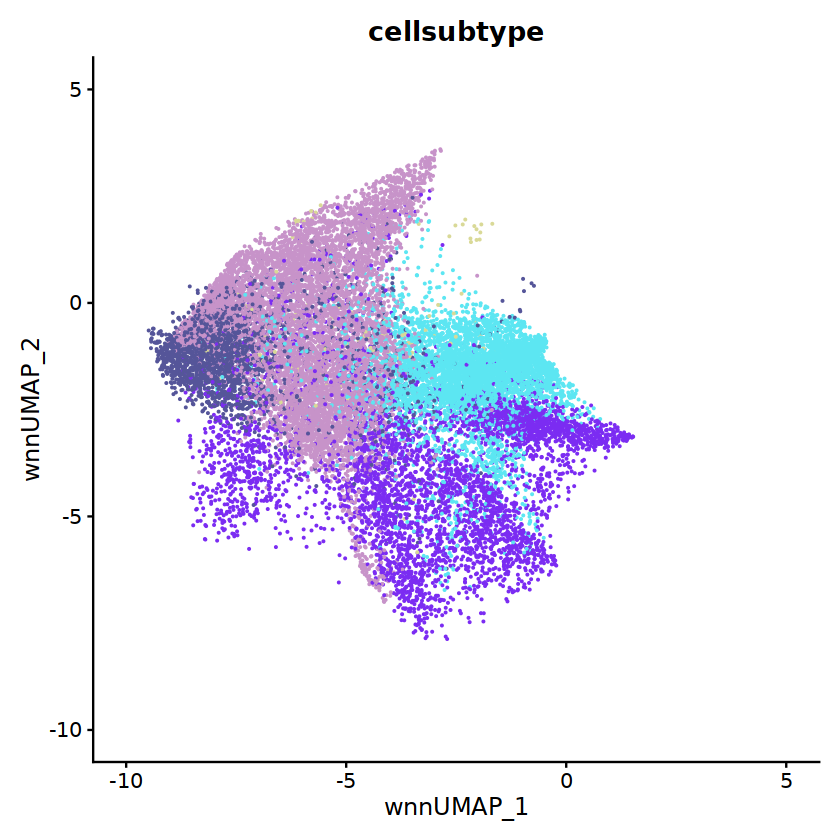

In [14]:
DimPlot(adata_fib, reduction='umap.wnn', group.by='cellsubtype', cols = Hep.colors) + 
    xlim(-10,5) + ylim(-10,5) + NoLegend()

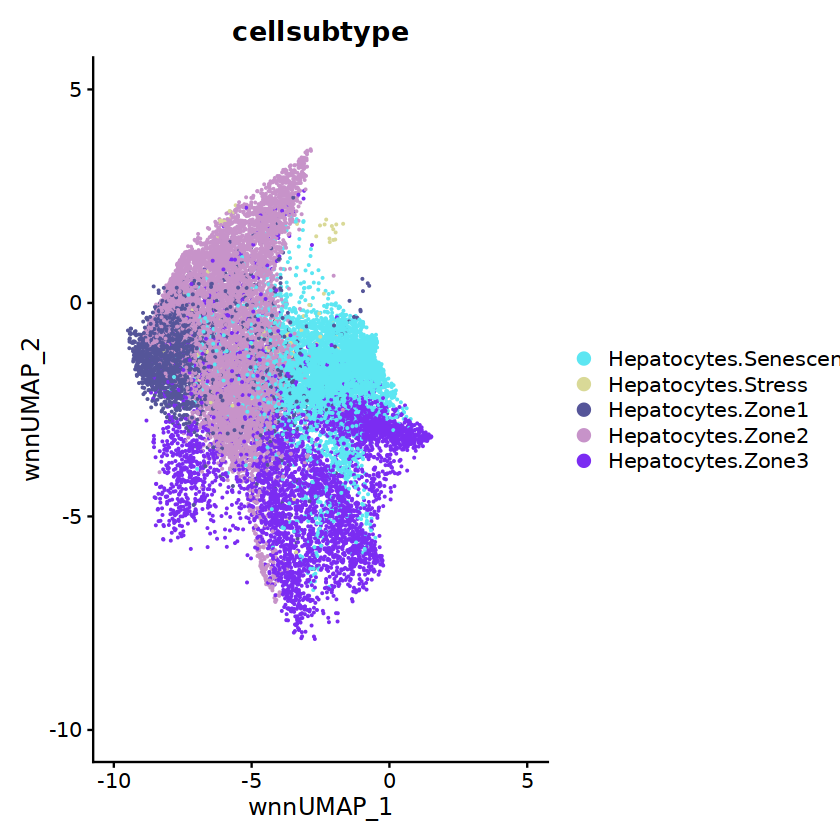

In [15]:
DimPlot(adata_fib, reduction='umap.wnn', group.by='cellsubtype', cols = Hep.colors) + 
    xlim(-10,5) + ylim(-10,5) 

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

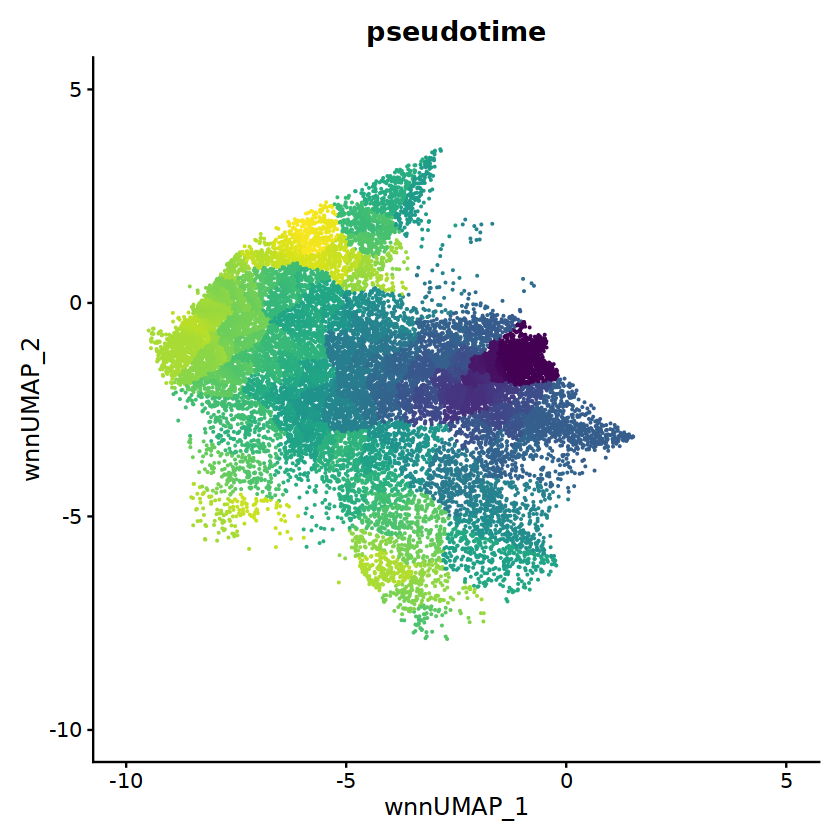

In [17]:
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis()

pdf('/nfs/lab/welison/Liver/Plots/250228_Fib+_Hepatocytes_pseudotime_viridis.pdf')
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis()
dev.off()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


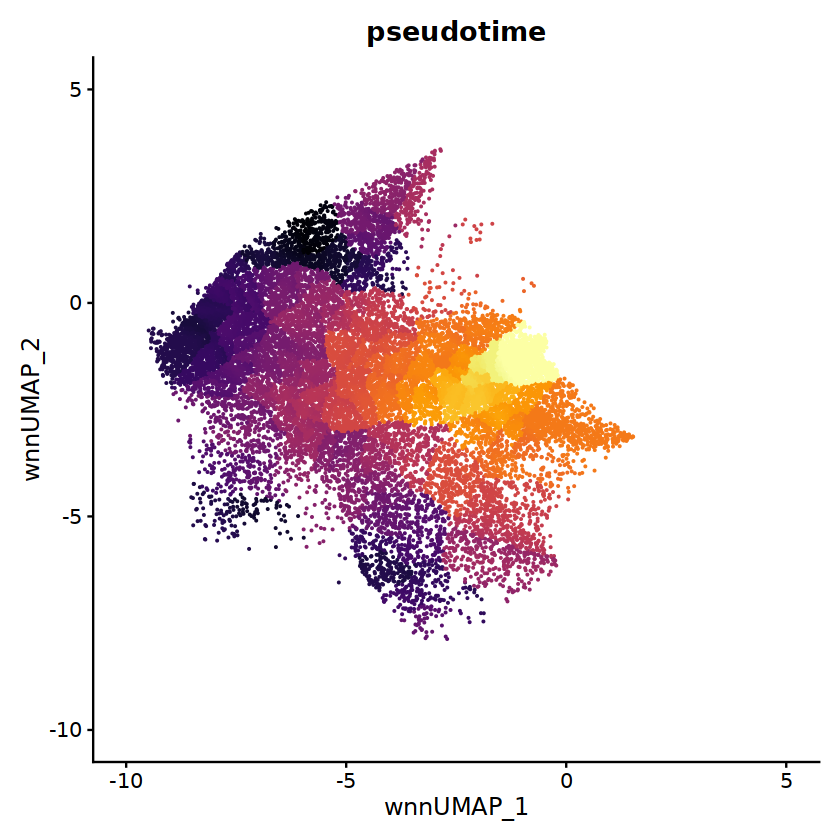

In [17]:
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis(option='inferno', direction=-1)

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

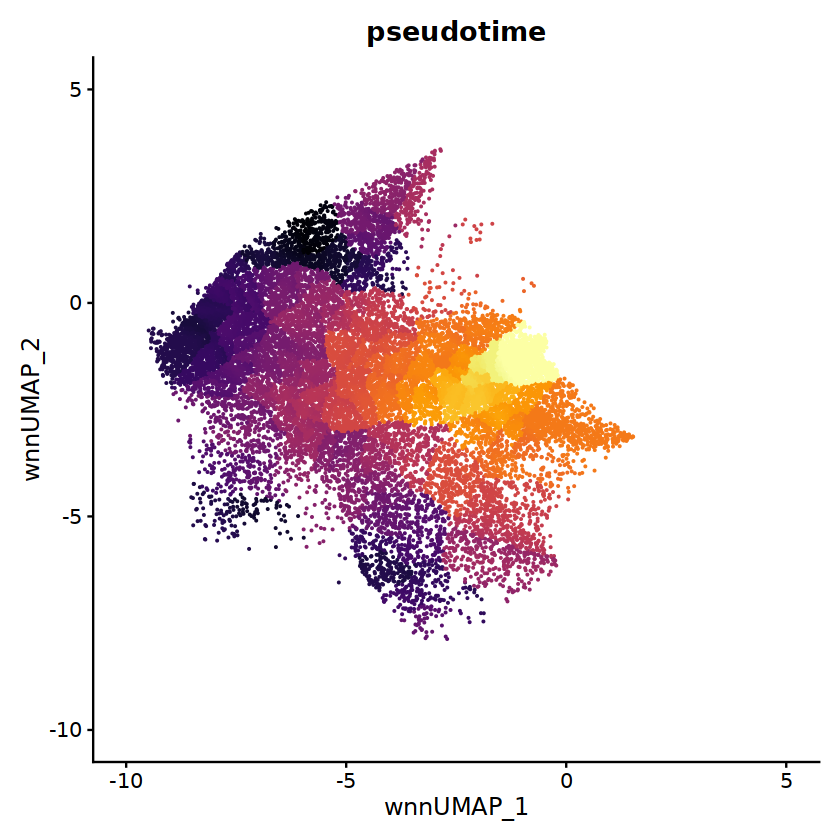

In [25]:
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis(option='inferno', direction=-1)

pdf('/nfs/lab/welison/Liver/Plots/250228_Fib+_Hepatocytes_pseudotime_plasma.pdf')
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis(option='inferno', direction = -1)
dev.off()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

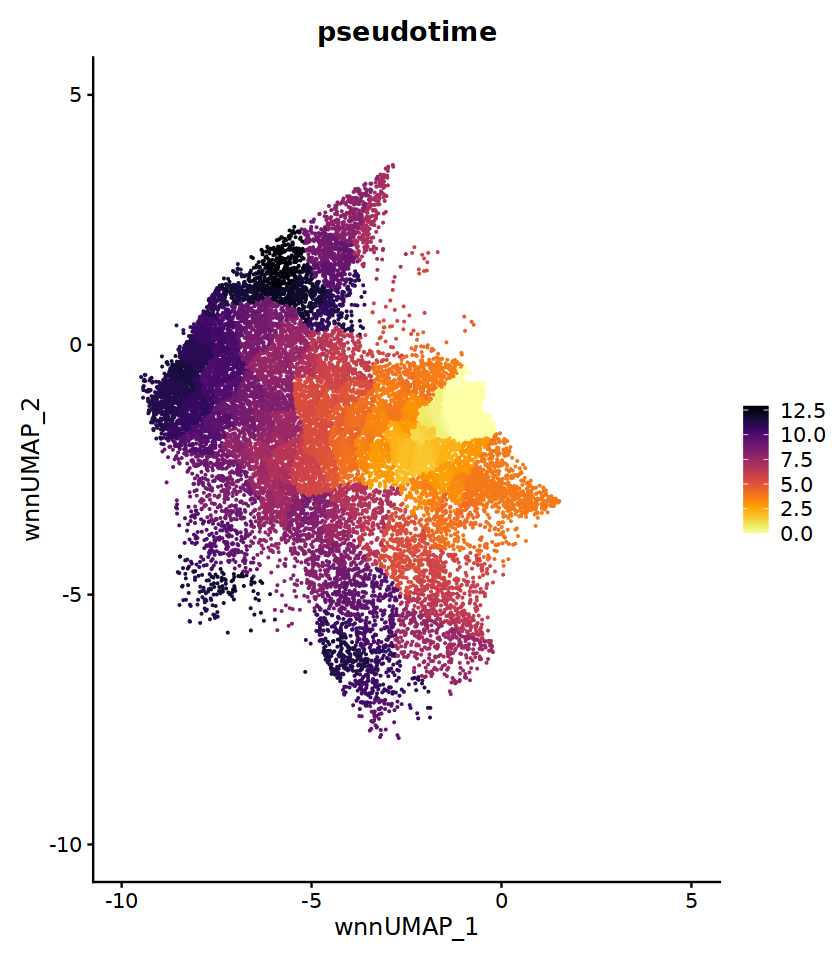

In [173]:
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5) + scale_color_viridis(option='inferno', direction=-1)

pdf('/nfs/lab/welison/Liver/Plots/250228_Fib+_Hepatocytes_pseudotime_plasma_legend.pdf')
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5) + scale_color_viridis(option='inferno', direction = -1)
dev.off()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
“Removed 61 rows containing missing values or values outside the scale range (`geom_point()`).”


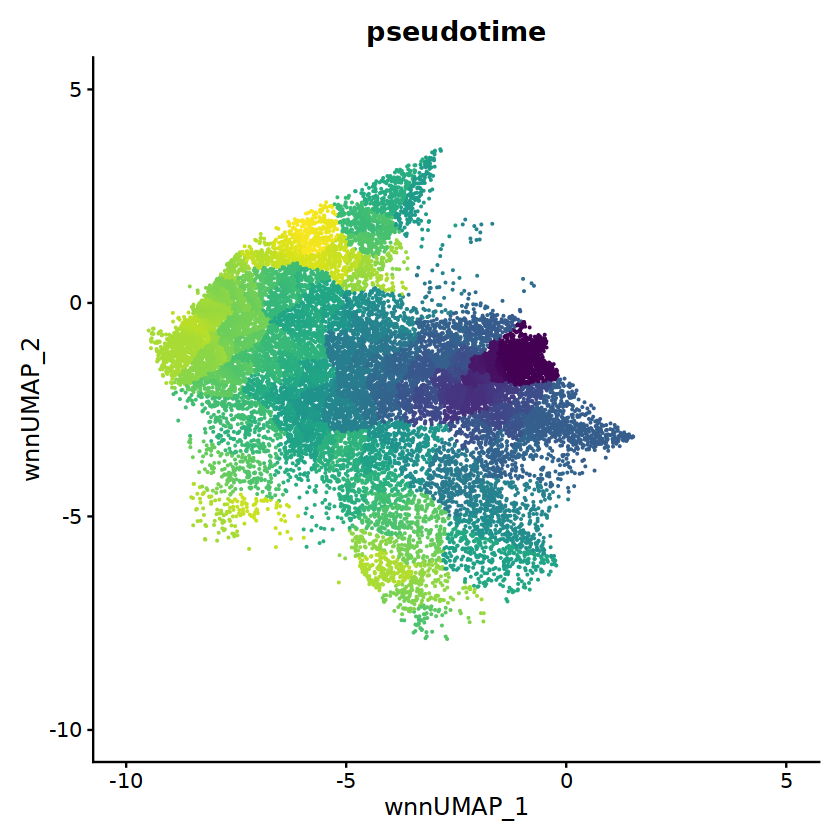

In [53]:
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis()

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 61 rows containing missing values or values outside the scale range (`geom_point()`).”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 61 rows containing missing values or values outside the scale range (`geom_point()`).”


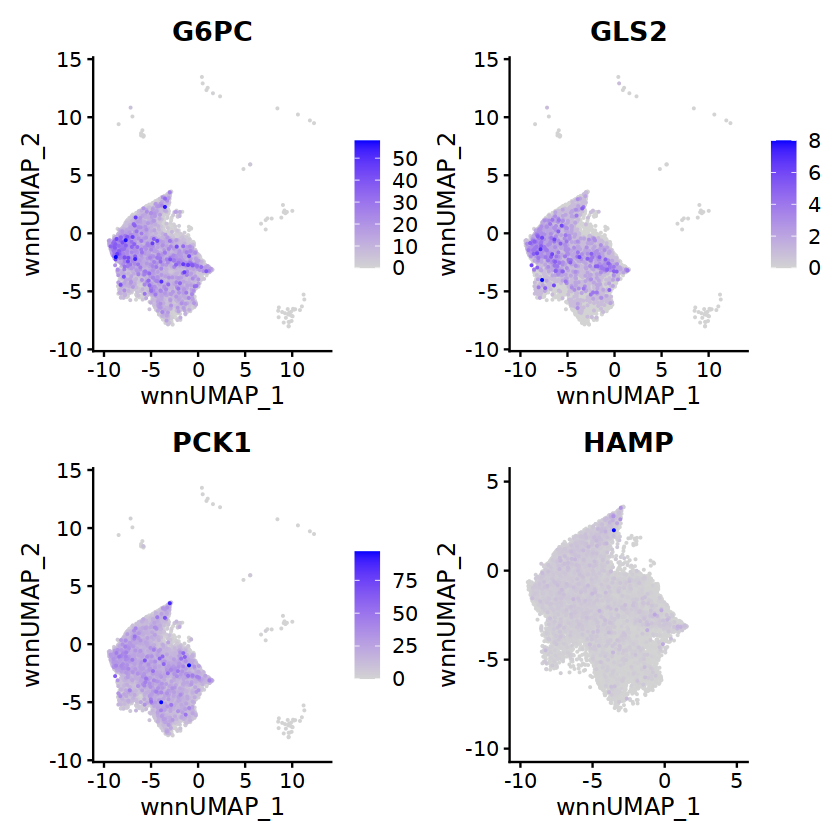

Warning message:
“The following requested variables were not found: CBP2”
Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 61 rows containing missing values or values outside the scale range (`geom_point()`).”


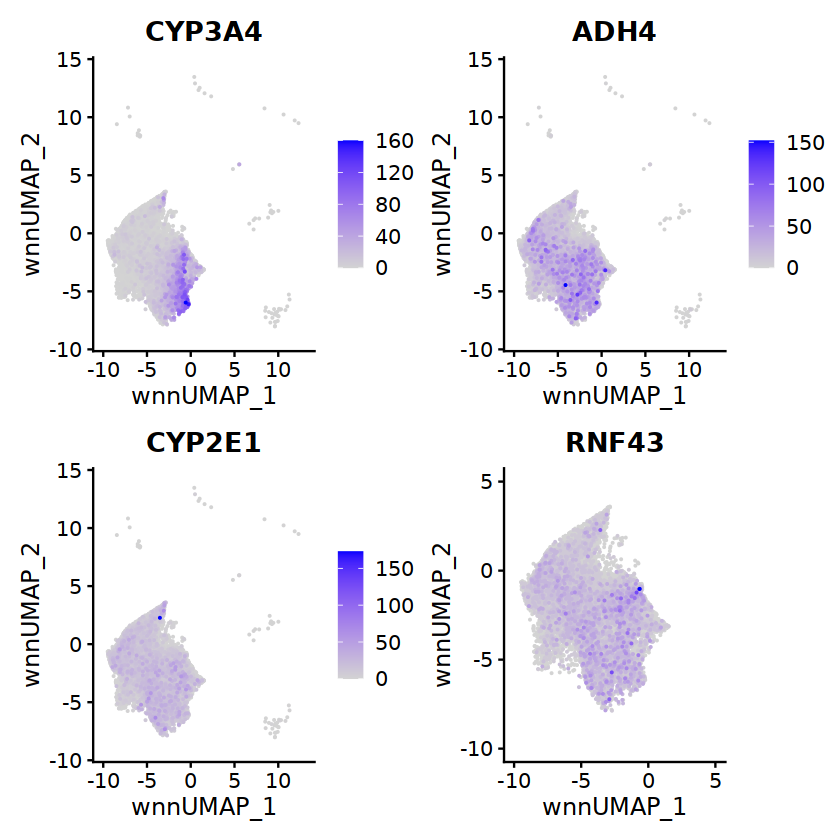

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 61 rows containing missing values or values outside the scale range (`geom_point()`).”


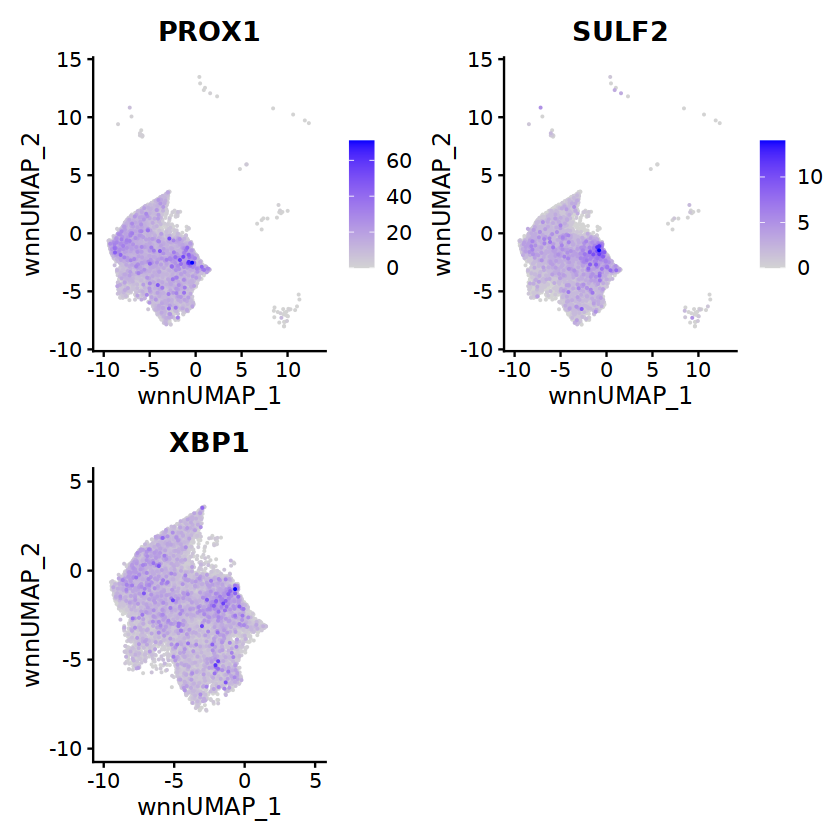

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Warning message:
“Removed 61 rows containing missing values or values outside the scale range (`geom_point()`).”


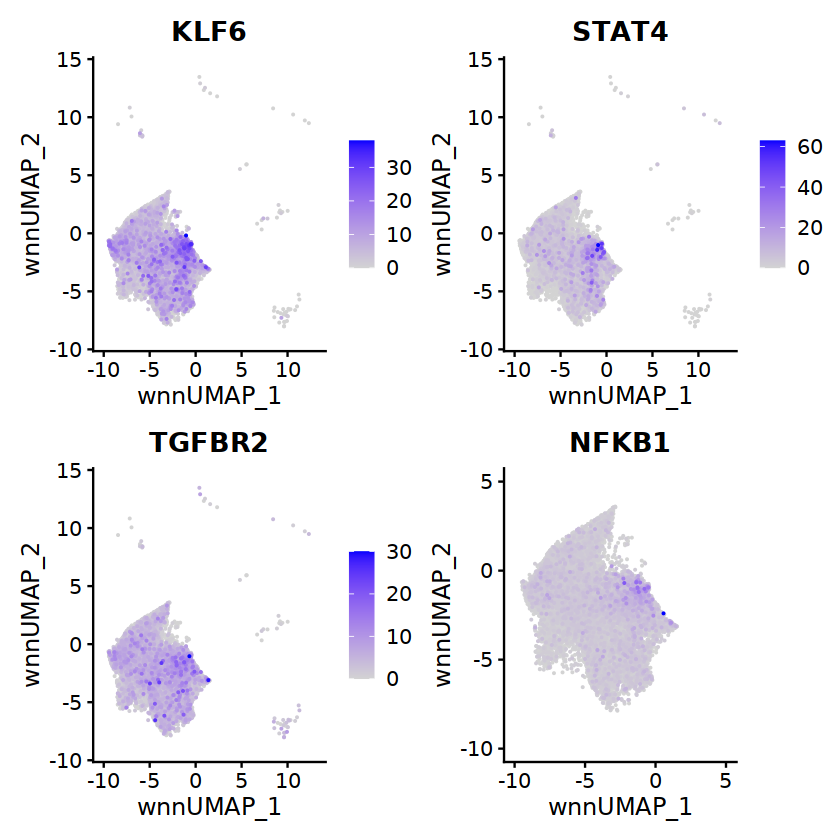

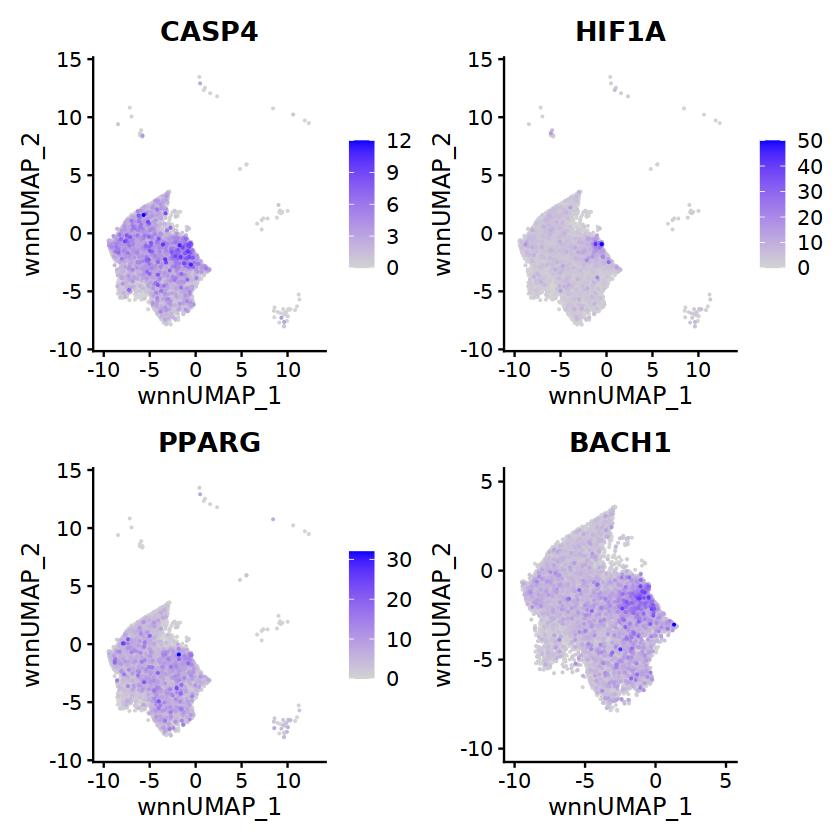

In [29]:
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = c('G6PC','GLS2','PCK1','HAMP'), order = T) + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend()
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = c('CYP3A4','ADH4','CYP2E1','RNF43'), order = T) + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend()
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = c('PROX1','CBP2','SULF2','XBP1'), order = T) + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend()
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = c('KLF6','STAT4','TGFBR2','NFKB1'), order = T) + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend()
FeaturePlot(adata_fib, reduction = 'umap.wnn', features = c('CASP4','HIF1A','PPARG','BACH1'), order = T) + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend()

In [26]:
adata_bulk <- AggregateExpression(adata_fib, group.by = c('donor_demux', 'cellsubtype'), return.seurat = T)
adata_bulk

Centering and scaling data matrix



An object of class Seurat 
986876 features across 72 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 3 layers present: counts, data, scale.data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks

In [27]:
adata_bulk[[]] <- left_join(adata_bulk[[]], trajectory %>%
    select(donor_demux, cellsubtype, pseudotime) %>%
    group_by(donor_demux, cellsubtype) %>%
    summarise(pseudotime=mean(pseudotime)))

`summarise()` has grouped output by 'donor_demux'. You can override using the `.groups` argument.
Joining with `by = join_by(donor_demux, cellsubtype)`


pdf 
  2

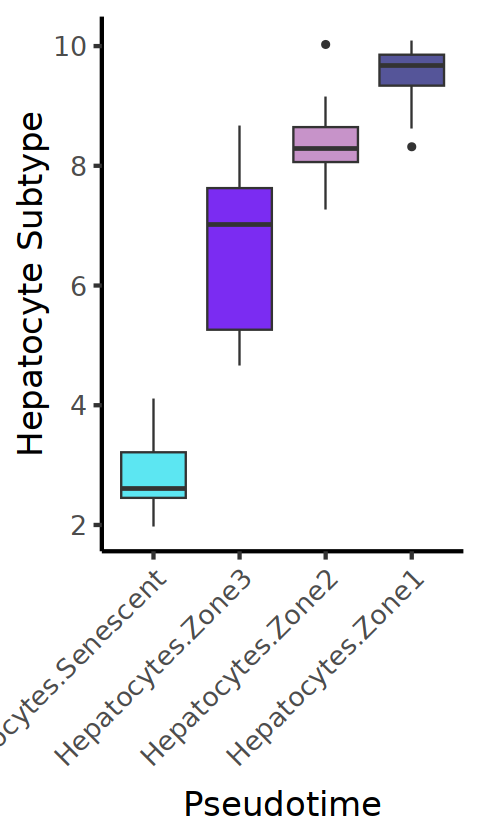

In [34]:
options(repr.plot.width=4)
plot.data <- adata_bulk[[]]
plot.data <- filter(plot.data, cellsubtype != 'Hepatocytes.Stress')
plot.data$cellsubtype <- factor(plot.data$cellsubtype, levels=rev(c('Hepatocytes.Zone1','Hepatocytes.Zone2',
                                                               'Hepatocytes.Zone3','Hepatocytes.Senescent')))

p1 <- ggplot(plot.data, aes(x=cellsubtype, y=pseudotime, fill=cellsubtype)) + geom_boxplot() +
    scale_fill_manual(values=Hep.colors) + theme_classic(base_size=20) + 
    ylab('Hepatocyte Subtype') + xlab('Pseudotime') + NoLegend() + 
    theme(axis.text.x = element_text(angle = 45, hjust=1))

p1

pdf('/nfs/lab/welison/Liver/Plots/250301_Pseudotime_Boxplot.pdf', width=6) 
p1
dev.off()
options(repr.plot.width=8)

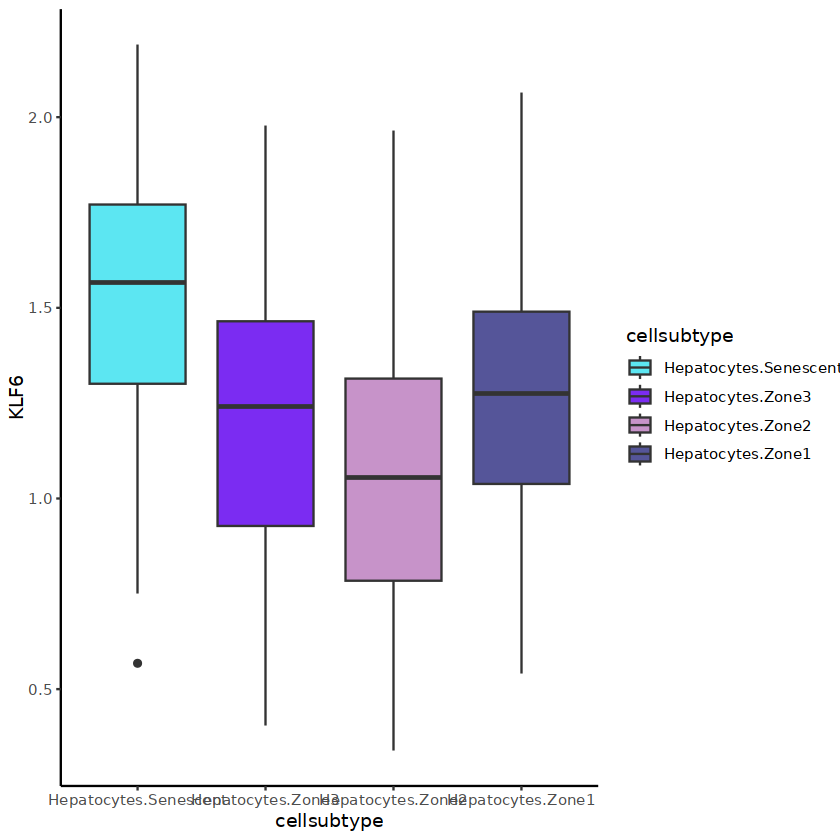

In [68]:
plot.data= data.frame(KLF6=adata_bulk$RNA$data['KLF6',], pseudotime=adata_bulk$pseudotime, cellsubtype=adata_bulk$cellsubtype)
plot.data <- filter(plot.data, cellsubtype != 'Hepatocytes.Stress')
plot.data$cellsubtype <- factor(plot.data$cellsubtype, levels=rev(c('Hepatocytes.Zone1','Hepatocytes.Zone2',
                                                               'Hepatocytes.Zone3','Hepatocytes.Senescent')))

ggplot(plot.data, aes(x=cellsubtype, y=KLF6, fill=cellsubtype)) + geom_boxplot() +
     scale_fill_manual(values=Hep.colors) + theme_classic()

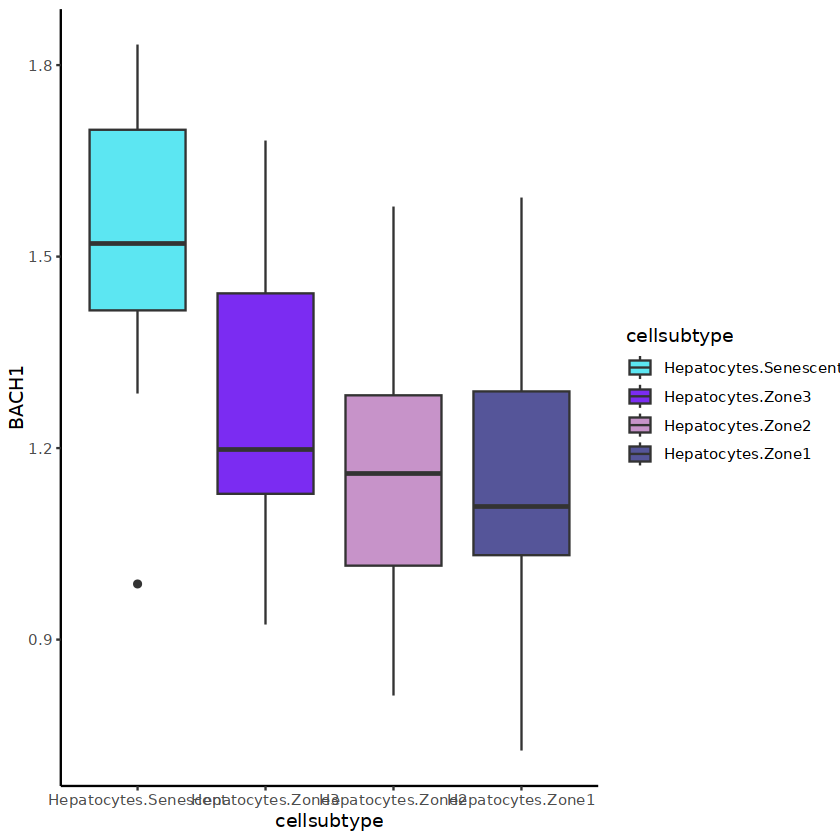

In [69]:
plot.data= data.frame(BACH1=adata_bulk$RNA$data['BACH1',], pseudotime=adata_bulk$pseudotime, cellsubtype=adata_bulk$cellsubtype)
plot.data <- filter(plot.data, cellsubtype != 'Hepatocytes.Stress')
plot.data$cellsubtype <- factor(plot.data$cellsubtype, levels=rev(c('Hepatocytes.Zone1','Hepatocytes.Zone2',
                                                               'Hepatocytes.Zone3','Hepatocytes.Senescent')))

ggplot(plot.data, aes(x=cellsubtype, y=BACH1, fill=cellsubtype)) + geom_boxplot() +
     scale_fill_manual(values=Hep.colors) + theme_classic()

In [118]:
adata_bulk_zone <- subset(adata_bulk, cellsubtype != 'Hepatocytes.Senescent')
adata_bulk
adata_bulk_zone

An object of class Seurat 
986876 features across 72 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 3 layers present: counts, data, scale.data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks

An object of class Seurat 
986876 features across 56 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 3 layers present: counts, data, scale.data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks

In [105]:
unbin.lm <- function(gene, all_genes) {
  #message(which(all_genes == gene))
  data=data.frame(gene.counts=adata_fib$RNA$data[gene,], pseudotime_bin=adata_fib$pseudotime_bin, 
                  cellsubtype=adata_fib$cellsubtype, donor=adata_fib$donor_demux)
  model <- lm(gene.counts ~ pseudotime_bin + donor, data = data)
  res <- filter(broom::tidy(model), term=='pseudotime_bin')
  res$gene <- gene
  res
}

In [88]:
bin.lm <- function(gene, all_genes) {
  #message(which(all_genes == gene))
  data=data.frame(gene.counts=adata_fib$RNA$data[gene,], pseudotime_bin=adata_fib$pseudotime_bin, 
                  cellsubtype=adata_fib$cellsubtype, donor=adata_fib$donor_demux)%>%
            group_by(pseudotime_bin) %>%
            summarise(gene.counts=sum(gene.counts))
  model <- lm(gene.counts ~ pseudotime_bin, data = data)
  res <- filter(broom::tidy(model), term=='pseudotime_bin')
  res$gene <- gene
  res$r.squared <- summary(model)$r.squared
  res
}

In [51]:
adata_fib

An object of class Seurat 
986876 features across 21103 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [60]:
nrow(adata_fib$RNA$data)
nrow(adata_fib$RNA$data[rowSums(adata_fib$RNA$data) > 21103,])

[1] 36601

[1] 1576

In [22]:


# Set up parallel processing
plan(multicore, workers = parallel::detectCores() - 1)  # Use all but one core
options(future.globals.maxSize = 20 * 1024^3) # Increase limit to 20 GiB

all_genes <- rownames(adata_fib$RNA$data[rowSums(adata_fib$RNA$data) > 500,])

# Run in parallel
gam_pval_list <- future_lapply(all_genes, function(g) bin.lm(g, all_genes))

# Combine results into a data frame
gam_pval <- bind_rows(gam_pval_list)

# Check results
gam_pval


In [91]:
# Set up parallel processing
plan(multicore, workers = parallel::detectCores() / 8)  # Use all but one core
options(future.globals.maxSize = 20 * 1024^3) # Increase limit to 20 GiB

all_genes <- rownames(adata_fib$RNA$data[rowSums(adata_fib$RNA$data) > 500,])

# Run in parallel
gam_pval_list_bin <- future_lapply(all_genes, function(g) bin.lm(g, all_genes))

# Combine results into a data frame
gam_pval_bin <- bind_rows(gam_pval_list_bin)
gam_pval_bin <- mutate(gam_pval_bin, qvalue=qvalue(p.value)$qvalues)

# Check results
gam_pval_bin


term,estimate,std.error,statistic,p.value,gene,r.squared,qvalue
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
pseudotime_bin,-0.40436975,0.10021407,-4.0350597,1.950854e-04,LINC01409,0.253286783,2.685754e-05
pseudotime_bin,-1.11130852,0.13701991,-8.1105622,1.499709e-10,LINC01128,0.578137758,1.431332e-10
pseudotime_bin,-0.07620648,0.03877140,-1.9655333,5.515259e-02,LINC00115,0.074490433,5.722160e-03
pseudotime_bin,-0.98208884,0.15388239,-6.3820741,6.522511e-08,NOC2L,0.459038323,1.798034e-08
pseudotime_bin,-0.73176471,0.11604337,-6.3059587,8.532817e-08,HES4,0.453085659,2.276526e-08
pseudotime_bin,-0.37877551,0.07325985,-5.1703015,4.502821e-06,ISG15,0.357705016,8.046454e-07
pseudotime_bin,-0.61675870,0.13664106,-4.5137142,4.129384e-05,AGRN,0.297974824,6.252598e-06
pseudotime_bin,-1.22232893,0.16265374,-7.5149143,1.199864e-09,C1orf159,0.540555270,6.658295e-10
pseudotime_bin,-0.70290516,0.09320574,-7.5414368,1.093237e-09,SDF4,0.542304720,6.202096e-10


In [90]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13724400,733.0,19939817,1065.0,19939817,1065.0
Vcells,1358850498,10367.3,6231665940,47543.9,14330916561,109336.3


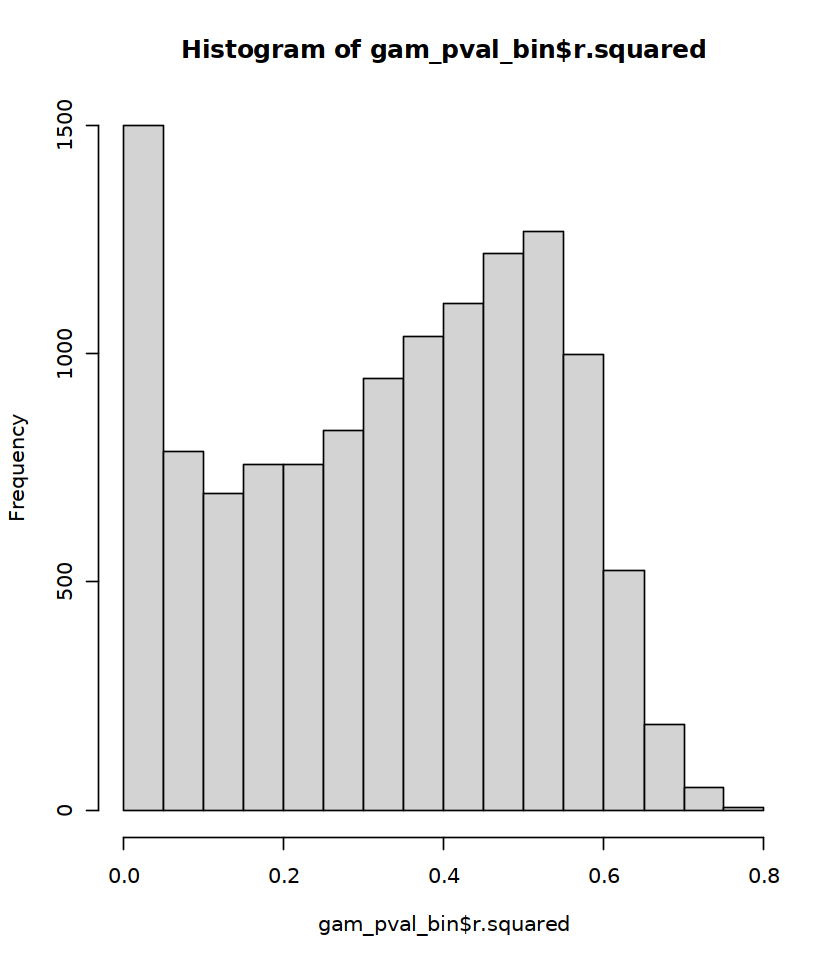

In [100]:
hist(gam_pval_bin$r.squared)

In [93]:
sum(gam_pval_bin$p.value < 0.05)
sum(p.adjust(gam_pval_bin$p.value, method='fdr') < 0.05)

[1] 10717

[1] 10637

In [99]:
sum(filter(gam_pval_bin, r.squared > 0.5)$p.value < 0.05)
sum(p.adjust(filter(gam_pval_bin, r.squared > 0.5)$p.value, method='fdr') < 0.05)

[1] 3035

[1] 3035

In [126]:
sum(gam_pval$p.value < 0.05)
sum(p.adjust(gam_pval$p.value, method='fdr') < 0.05)

[1] 11307

[1] 11267

In [27]:
gam_pval_bin %>%
    filter(estimate < 0 & p.value < 0.01) %>%
    arrange(estimate)

term,estimate,std.error,statistic,p.value,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
pseudotime_bin,-2474.46334,323.686311,-7.644634,7.613982e-10,MALAT1
pseudotime_bin,-634.34372,71.865420,-8.826828,1.276999e-11,NEAT1
pseudotime_bin,-149.98900,15.601251,-9.613909,9.045581e-13,PTGR1
pseudotime_bin,-145.32605,18.051414,-8.050674,1.846390e-10,LINC02336
pseudotime_bin,-114.26194,14.563583,-7.845730,3.769420e-10,GBE1
pseudotime_bin,-113.07534,11.985965,-9.433979,1.646846e-12,DTNA
pseudotime_bin,-109.39309,18.521284,-5.906345,3.484212e-07,AL136456.1
pseudotime_bin,-105.64567,10.919790,-9.674697,7.394180e-13,CYP3A5
pseudotime_bin,-100.74353,10.783763,-9.342149,2.239101e-12,LRMDA


In [115]:
gam_pval %>%
    filter(estimate < 0 & p.value < 0.01) %>%
    arrange(estimate)

term,estimate,std.error,statistic,p.value,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
pseudotime_bin,-5.5920164,0.110045241,-50.81561,0.000000e+00,MALAT1
pseudotime_bin,-1.3248816,0.045823222,-28.91289,2.687580e-180,NEAT1
pseudotime_bin,-0.3325385,0.006403357,-51.93191,0.000000e+00,PTGR1
pseudotime_bin,-0.3182349,0.005364529,-59.32204,0.000000e+00,LINC02336
pseudotime_bin,-0.2633395,0.006486949,-40.59527,0.000000e+00,LRMDA
pseudotime_bin,-0.2519491,0.005851276,-43.05883,0.000000e+00,GBE1
pseudotime_bin,-0.2504637,0.011718157,-21.37399,2.704128e-100,AL136456.1
pseudotime_bin,-0.2458412,0.004146707,-59.28587,0.000000e+00,DTNA
pseudotime_bin,-0.2387196,0.008825475,-27.04892,1.978033e-158,GPC6


In [117]:
gam_pval %>%
    filter(estimate < 0 & p.value < 0.01) %>%
    arrange(estimate) %>%
    select(gene) %>%
    unlist()

gene1            gene2            gene3            gene4 
        "MALAT1"          "NEAT1"          "PTGR1"      "LINC02336" 
           gene5            gene6            gene7            gene8 
         "LRMDA"           "GBE1"     "AL136456.1"           "DTNA" 
           gene9           gene10           gene11           gene12 
          "GPC6"         "CYP3A5"         "ZBTB20"           "ASPH" 
          gene13           gene14           gene15           gene16 
        "IMMP2L"           "SOD2"           "FHIT"        "ZNF385D" 
          gene17           gene18           gene19           gene20 
          "EXT1"         "AKR1C1"          "PLCG2"          "TSHZ2" 
          gene21           gene22           gene23           gene24 
         "MYRIP"         "SQSTM1"         "CASC19"         "AKR1C2" 
          gene25           gene26           gene27           gene28 
         "MAST4"           "SOX5"         "TXNRD1"         "ZFAND3" 
          gene29           gene30           gene31           gene32 
           "LPP"           "VMP1"          "BICC1"          "ABCC2" 
          gene33           gene34           gene35           gene36 
         "MGST1"          "MBNL2"         "FNDC3B"            "DST" 
          gene37           gene38           gene39           gene40 
      "SERPINE1"          "PTPRM"          "PLOD2"      "LINC02015" 
          gene41           gene42           gene43           gene44 
      "ADAMTS17"         "LPGAT1"           "PCCA"          "PLIN2" 
          gene45           gene46           gene47           gene48 
         "PTPRK"           "GPAM"            "GDA"         "NCKAP5" 
          gene49           gene50           gene51           gene52 
         "WDPCP"        "ALDH1A1"           "NRG1"            "FN1" 
          gene53           gene54           gene55           gene56 
         "HKDC1"          "ABCB4"          "MAML3"            "FTX" 
          gene57           gene58           gene59           gene60 
        "SAMD4A"         "TRMT11"           "NFIA"      "LINC01151" 
          gene61           gene62           gene63           gene64 
        "DIAPH2"    "PALM2-AKAP2"           "MDM2"        "AKR1B10" 
          gene65           gene66           gene67           gene68 
          "CBLB"          "ABCC3"         "CYP3A4"         "SPTBN1" 
          gene69           gene70           gene71           gene72 
          "AFF3"      "LINC01344"        "MAP3K13"          "ABHD2" 
          gene73           gene74           gene75           gene76 
          "A1CF"          "CHST9"         "PARD3B"            "FTL" 
          gene77           gene78           gene79           gene80 
        "ABLIM3"          "NCOA2"          "EPB41"          "FGF12" 
          gene81           gene82           gene83           gene84 
      "RABGAP1L"         "KLHL29"          "ASCC3"         "NEDD4L" 
          gene85           gene86           gene87           gene88 
         "PARD3"           "TRIO"         "ABLIM1"          "AOPEP" 
          gene89           gene90           gene91           gene92 
         "PTPRG"         "EIF4G3"          "FGF13"        "SPATS2L" 
          gene93           gene94           gene95           gene96 
         "ITGAV"          "MBNL1"           "SOX6"          "AGAP1" 
          gene97           gene98           gene99          gene100 
         "PRKCA"        "L3MBTL4"          "MACF1"          "SHTN1" 
         gene101          gene102          gene103          gene104 
          "PATJ"         "TBC1D5"        "DENND1A"           "BAAT" 
         gene105          gene106          gene107          gene108 
       "PIK3C2G"         "SH3D19"            "ADK"         "JMJD1C" 
         gene109          gene110          gene111          gene112 
        "HNRNPC"        "SHROOM3"          "TCF12"          "CALD1" 
         gene113          gene114          gene115          gene116 
         "ITPR2"           "EPS8"           "KYNU"          "BACH1" 
         

In [107]:
gam_pval %>%
    filter(estimate < 0) %>%
    arrange(p.value)

term,estimate,std.error,statistic,p.value,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
pseudotime_bin,-0.06954461,0.0015191808,-45.77771,0,EPB41
pseudotime_bin,-0.07209064,0.0018192966,-39.62556,0,LINC01344
pseudotime_bin,-0.09794555,0.0021107133,-46.40400,0,LPGAT1
pseudotime_bin,-0.04774716,0.0011242453,-42.47041,0,RAB10
pseudotime_bin,-0.07394822,0.0018459114,-40.06055,0,SPTBN1
pseudotime_bin,-0.06322747,0.0013987796,-45.20188,0,ITGAV
pseudotime_bin,-0.04488434,0.0010228769,-43.88049,0,AGFG1
pseudotime_bin,-0.04992899,0.0011946681,-41.79319,0,MAP4
pseudotime_bin,-0.25194908,0.0058512758,-43.05883,0,GBE1


In [108]:
gam_pval %>%
    filter(estimate < 0) %>%
    arrange(p.value) %>%
    select(gene) %>%
    unlist()

gene1            gene2            gene3            gene4 
         "EPB41"      "LINC01344"         "LPGAT1"          "RAB10" 
           gene5            gene6            gene7            gene8 
        "SPTBN1"          "ITGAV"          "AGFG1"           "MAP4" 
           gene9           gene10           gene11           gene12 
          "GBE1"      "LINC02015"         "SQSTM1"           "CAP2" 
          gene13           gene14           gene15           gene16 
           "ME1"           "SOD2"        "AKR1B10"           "ASPH" 
          gene17           gene18           gene19           gene20 
     "LINC01151"         "CASC19"           "PVT1"          "PLIN2" 
          gene21           gene22           gene23           gene24 
         "PCSK5"          "PTGR1"           "UGCG"         "AKR1C1" 
          gene25           gene26           gene27           gene28 
        "AKR1C2"       "ARHGAP12"          "BICC1"          "HKDC1" 
          gene29           gene30           gene31           gene32 
         "LRMDA"          "ABCC2"      "LINC01435"          "SHTN1" 
          gene33           gene34           gene35           gene36 
        "MALAT1"          "MGST1"         "TXNRD1"      "LINC02336" 
          gene37           gene38           gene39           gene40 
        "SAMD4A"          "ANXA2"        "SLC28A1"           "CES1" 
          gene41           gene42           gene43           gene44 
         "ABCC3"           "VMP1"          "PTPRM"           "DTNA" 
          gene45           gene46           gene47           gene48 
         "BACH1"         "SESTD1"         "VPS13C"          "FNIP1" 
          gene49           gene50           gene51           gene52 
        "IMMP2L"           "SUCO"        "SPATS2L"          "DAPK2" 
          gene53           gene54           gene55           gene56 
         "CALD1"           "CASK"         "SRGAP1"       "ADAMTS17" 
          gene57           gene58           gene59           gene60 
         "ASAP1"           "MYH9"          "MAST4"         "EIF4G3" 
          gene61           gene62           gene63           gene64 
          "FLNB"         "MAP4K4"           "FAT1"         "LUCAT1" 
          gene65           gene66           gene67           gene68 
      "SERPINE1"         "MICAL3"           "RGL1"          "CLIP1" 
          gene69           gene70           gene71           gene72 
         "AGAP1"           "ENAH"           "KLF6"          "LRCH1" 
          gene73           gene74           gene75           gene76 
          "PATJ"           "WTAP"           "IL32"         "TRMT11" 
          gene77           gene78           gene79           gene80 
           "MCU"         "DIAPH2"           "EPS8"         "RNF213" 
          gene81           gene82           gene83           gene84 
         "ANXA4"           "TPM1"        "PLA2G4C"        "PACSIN2" 
          gene85           gene86           gene87           gene88 
         "CYTOR"    "PALM2-AKAP2"         "SEL1L3"          "LAMC1" 
          gene89           gene90           gene91           gene92 
          "AAK1"          "PDZD8"           "OLA1"         "HNRNPC" 
          gene93           gene94           gene95           gene96 
        "RNF115"            "MBP"        "SLC20A2"          "WDFY2" 
          gene97           gene98           gene99          gene100 
        "NCKAP5"       "ITGB1-DT"         "ZFAND3"         "NEDD4L" 
         gene101          gene102          gene103          gene104 
         "CLDN1"    "MIR4435-2HG"           "CBLB"     "AC114812.2" 
         gene105          gene106          gene107          gene108 
          "FHIT"            "TXN"           "AFF3"          "HERC4" 
         gene109          gene110          gene111          gene112 
         "GNA13"           "PTK2"       "MIR34AHG"            "GSR" 
         gene113          gene114          gene115          gene116 
       "ALDH1A1"        "DENND1A"          "MACF1"          "NABP1" 
         

In [83]:
adata_fib

An object of class Seurat 
986876 features across 21103 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

Scale for x is already present.
Adding another scale for x, which will replace the existing scale.
Scale for y is already present.
Adding another scale for y, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


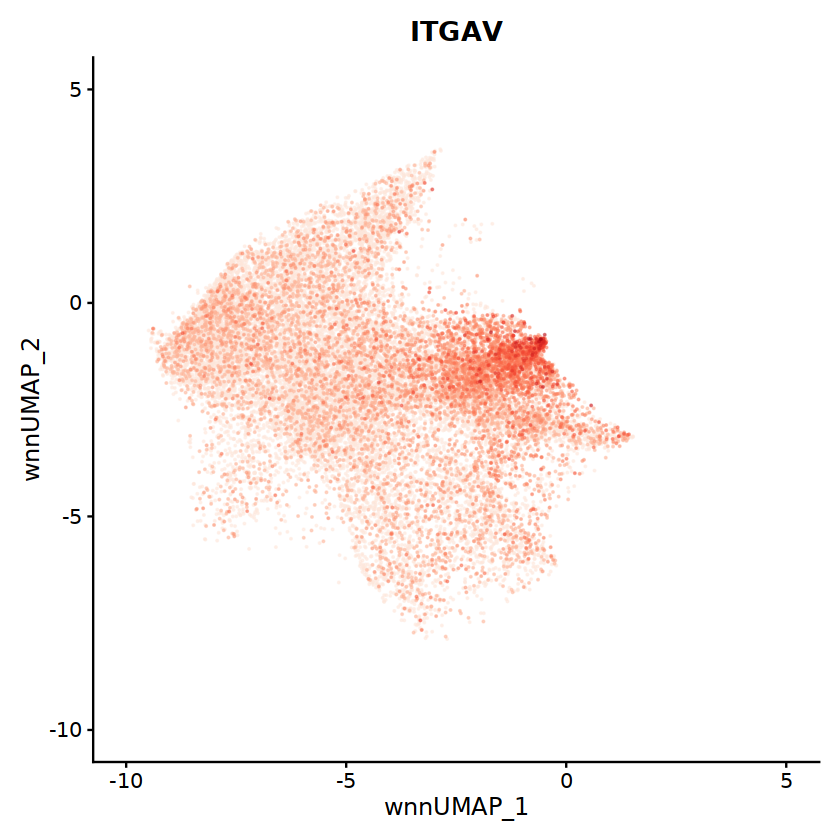

In [84]:
DefaultAssay(adata_fib) <- 'SCT'
FeaturePlot(adata_fib,reduction = 'umap.wnn', features = c('ITGAV'), order = T, alpha=0.5) + 
    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_distiller(palette = 'Reds', direction=1)

#pdf('/nfs/lab/welison/Liver/Plots/250228_Fib+_Hepatocytes_pseudotime_plasma.pdf')
#FeaturePlot(adata_fib, reduction = 'umap.wnn', features = 'pseudotime') + 
#    xlim(-10,5) + ylim(-10,5)  + NoLegend() + scale_color_viridis(option='inferno', direction = -1)
#dev.off()

In [28]:
bc.order <- adata_fib$pseudotime %>%
    sort() %>%
    names()

length(bc.order)
head(bc.order)

[1] 21103

[1] "QY_2406_2_QY_2405_2_GCCCAAATCCCGCCTA-1"
[2] "QY_2406_2_QY_2405_2_GATCCGTCAAGTTATC-1"
[3] "QY_2406_2_QY_2405_2_GGAGCGATCTTACTCG-1"
[4] "QY_2406_2_QY_2405_2_GACTATTCAAGCGAGC-1"
[5] "QY_2406_2_QY_2405_2_GGCCTTAAGGAACGGT-1"
[6] "QY_2406_2_QY_2405_2_GAAGCTAAGTATCGCG-1"

In [69]:
adata_fib

An object of class Seurat 
986876 features across 21103 samples within 5 assays 
Active assay: RNA (36601 features, 0 variable features)
 2 layers present: counts, data
 4 other assays present: SCT, Peaks.1, Peaks.2, Subtype.Peaks
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [52]:
# Load RColorBrewer

# Classic palette BuPu, with 4 colors
coul <- brewer.pal(12, "Reds") 

# Add more colors to this palette :
coul <- colorRampPalette(coul)(25)

In [70]:
adata_bin <- AggregateExpression(adata_fib, assays = c('RNA','SCT'), group.by = 'pseudotime_bin', return.seurat = T)
adata_bin

Centering and scaling data matrix



An object of class Seurat 
60356 features across 50 samples within 2 assays 
Active assay: RNA (36601 features, 0 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: SCT

In [48]:
library(qvalue)

In [49]:
gam_pval_bin <- mutate(gam_pval_bin, qvalue=qvalue(p.value)$qvalues)

dim(gam_pval_bin)
head(gam_pval_bin)

[1] 12671     7

term,estimate,std.error,statistic,p.value,gene,qvalue
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
pseudotime_bin,-0.40436975,0.10021407,-4.035060,1.950854e-04,LINC01409,2.685754e-05
pseudotime_bin,-1.11130852,0.13701991,-8.110562,1.499709e-10,LINC01128,1.431332e-10
pseudotime_bin,-0.07620648,0.03877140,-1.965533,5.515259e-02,LINC00115,5.722160e-03
pseudotime_bin,-0.98208884,0.15388239,-6.382074,6.522511e-08,NOC2L,1.798034e-08
pseudotime_bin,-0.73176471,0.11604337,-6.305959,8.532817e-08,HES4,2.276526e-08
pseudotime_bin,-0.37877551,0.07325985,-5.170301,4.502821e-06,ISG15,8.046454e-07


In [103]:
top.genes <- filter(gam_pval_bin, r.squared > 0.6) %>%
    filter(qvalue < 0.05) %>% #estimate < 0
    arrange(p.value) %>%
    select(gene) %>%
    #head(n=100) %>%
    unlist() 

length(top.genes)
head(top.genes)

[1] 768

gene1        gene2        gene3        gene4        gene5        gene6 
"AC025159.1"        "LPA"      "ABCB4"     "GRIN3A"       "FGL1"      "C4BPA"

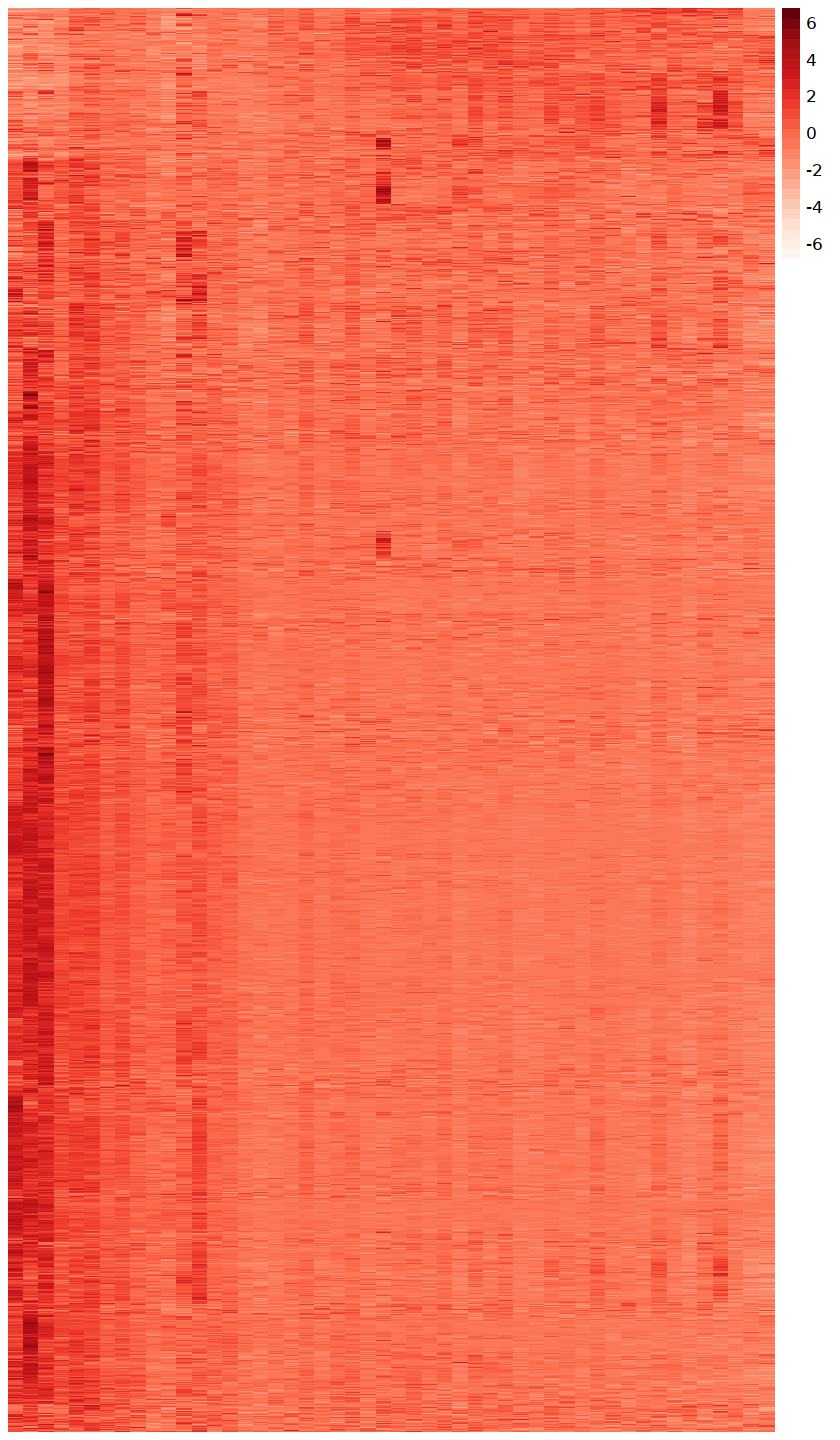

In [54]:
options(repr.plot.height=12)
adata_bin$RNA$counts[top.genes,] %>%
    pheatmap(cluster_rows = T, cluster_cols = F, show_colnames = F, scale='row', 
             color=coul, treeheight_row = 0, show_rownames = F)
options(repr.plot.height=8)

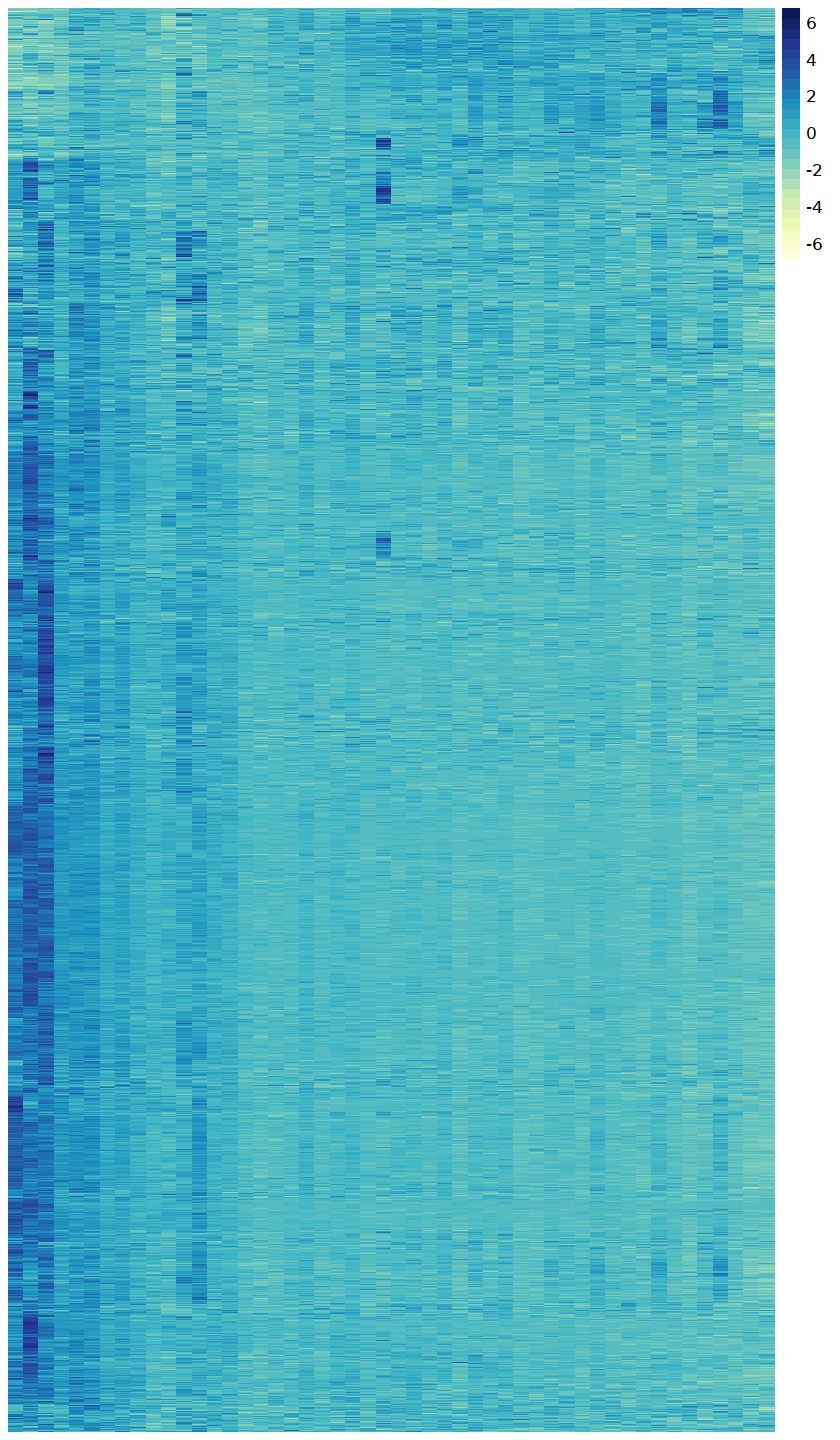

In [51]:
options(repr.plot.height=12)
adata_bin$RNA$counts[top.genes,] %>%
    pheatmap(cluster_rows = T, cluster_cols = F, show_colnames = F, scale='row', 
             color=coul, treeheight_row = 0, show_rownames = F)
options(repr.plot.height=8)

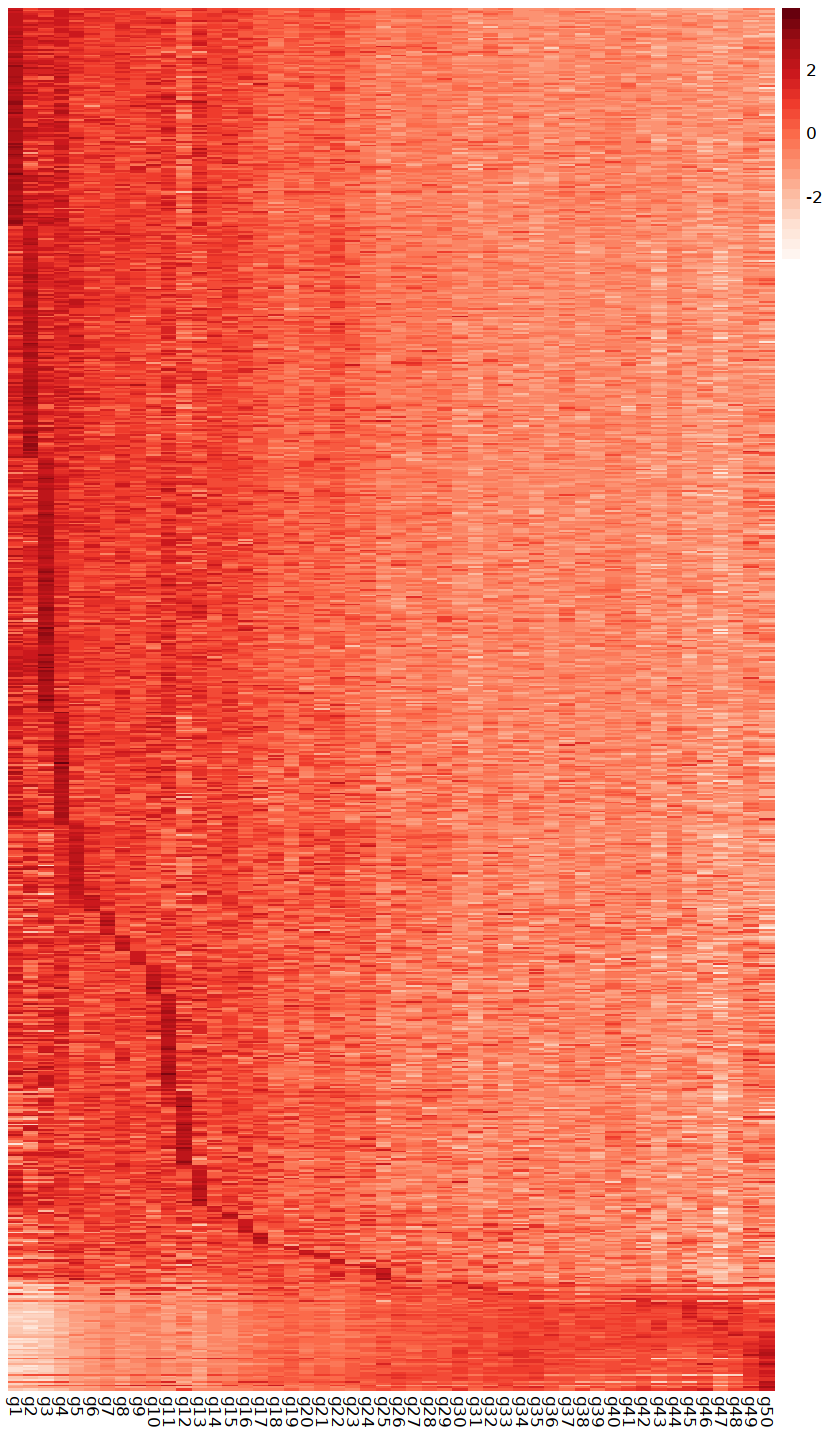

In [104]:
options(repr.plot.height=12)

mat <- adata_bin$RNA$data[top.genes,]
max_indices <- max.col(mat)
permutation_vector <- order(max_indices)
smat <- mat[permutation_vector, ]

smat %>%
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = T, scale='row', 
             color=coul, treeheight_row = 0, show_rownames = F)
options(repr.plot.height=8)

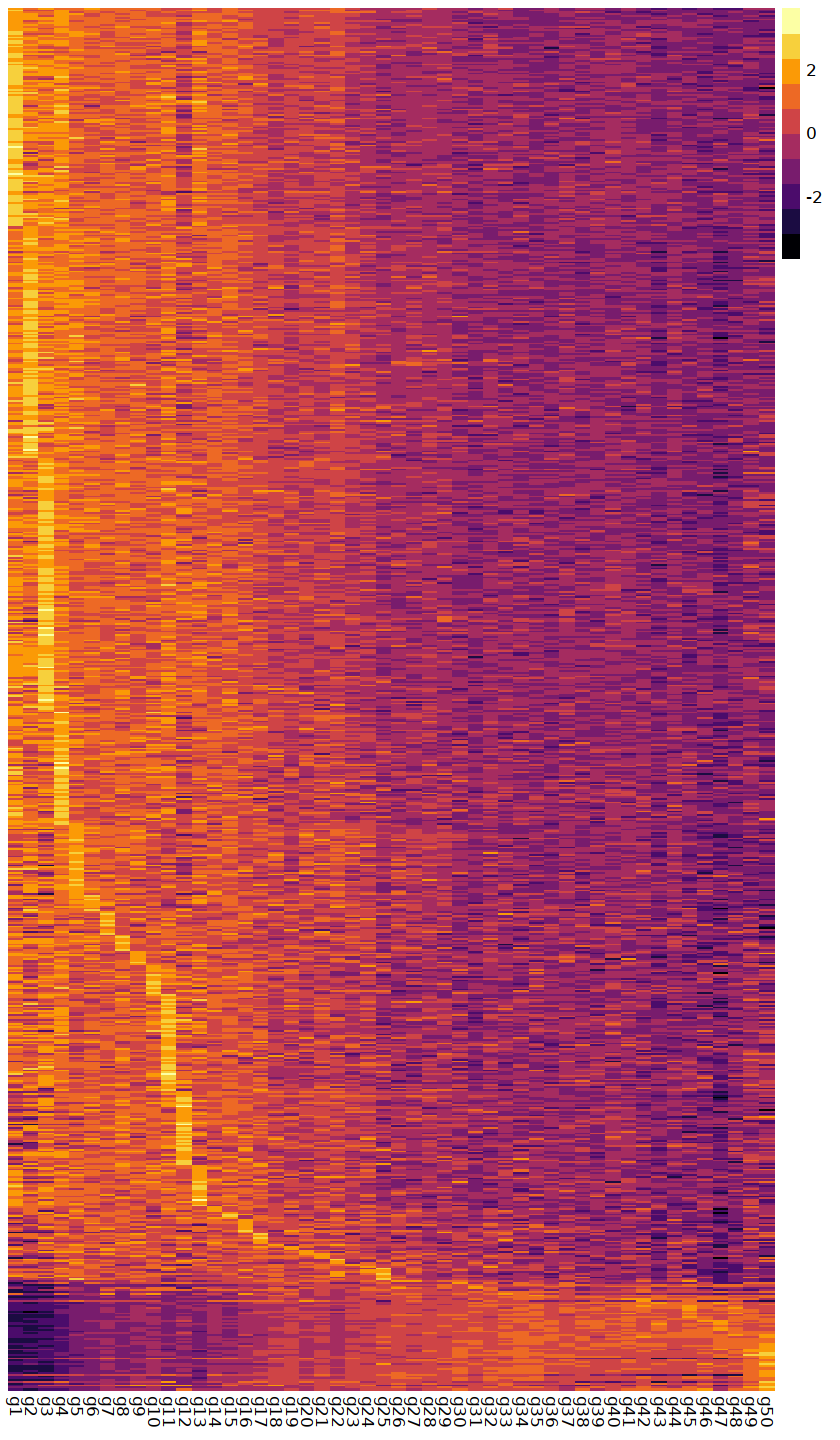

In [105]:
options(repr.plot.height=12)

mat <- adata_bin$RNA$data[top.genes,]
max_indices <- max.col(mat)
permutation_vector <- order(max_indices)
smat <- mat[permutation_vector, ]

smat %>%
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = T, scale='row', 
             color=inferno(10), treeheight_row = 0, show_rownames = F)
options(repr.plot.height=8)

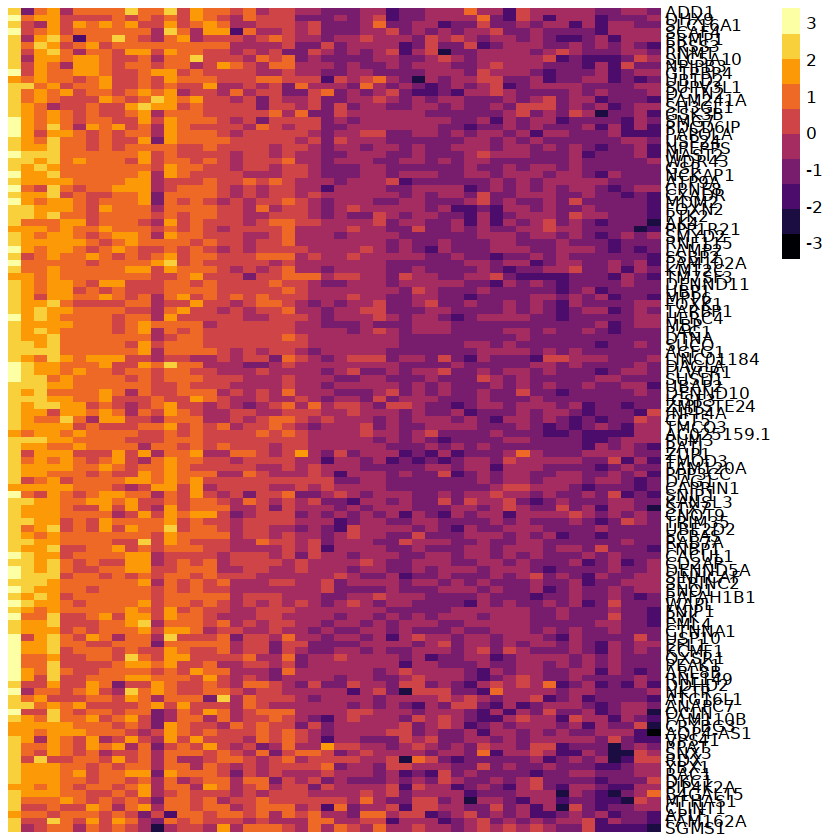

In [121]:
options(repr.plot.height=7)

mat <- adata_bin$RNA$data[top.genes,]
max_indices <- max.col(mat)
permutation_vector <- order(max_indices)
smat <- mat[permutation_vector, ]

smat[1:sum(max_indices == 1),] %>%
    pheatmap(cluster_rows = T, cluster_cols = F, show_colnames = F, scale='row', 
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

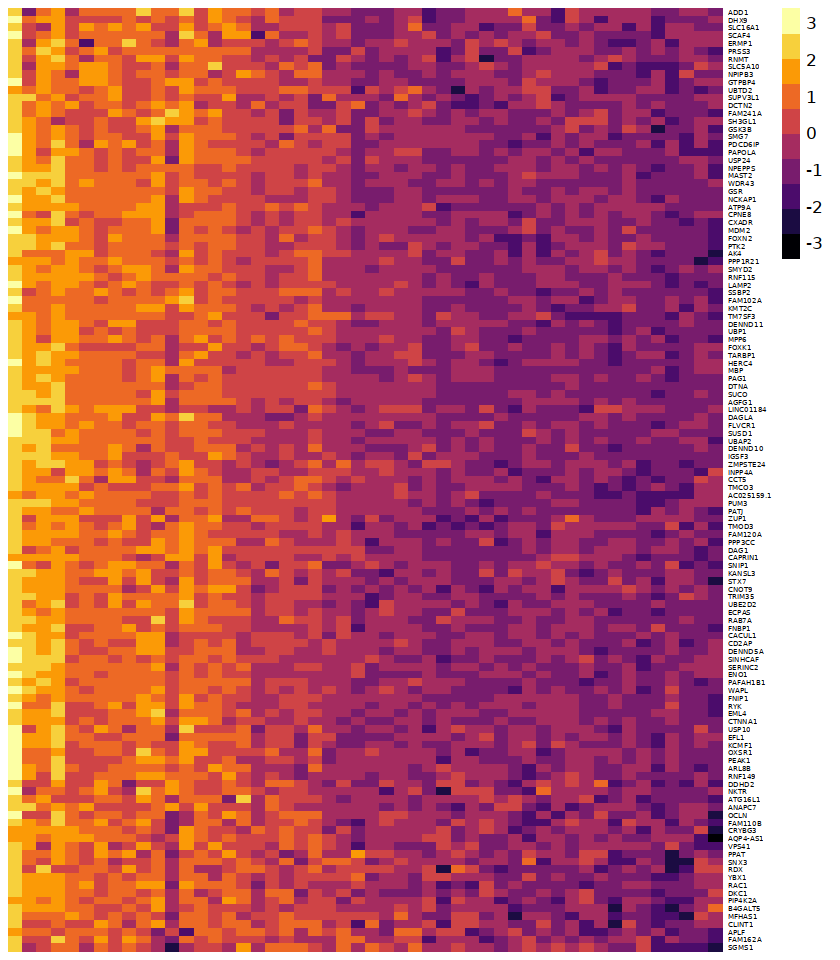

In [179]:
smat[1:sum(max_indices == 1),] %>%
    pheatmap(cluster_rows = T, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 4,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

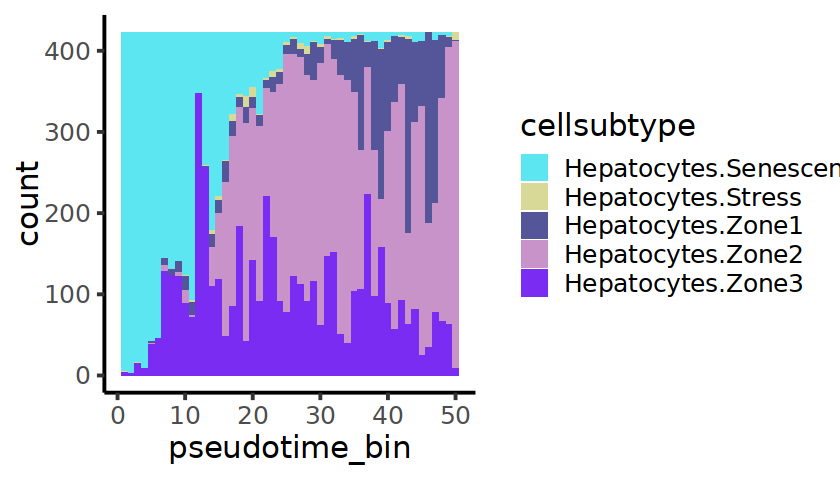

In [191]:
options(repr.plot.height=4)
select(adata_fib[[]], pseudotime_bin, cellsubtype) %>%
    ggplot(aes(x=pseudotime_bin, fill=cellsubtype)) + geom_bar() +
    theme_classic(base_size=18) + scale_fill_manual(values=Hep.colors)

In [153]:
bin.lm <- function(gene, all_genes) {
  #message(which(all_genes == gene))
  data=data.frame(gene.counts=adata_inj_z3$RNA$data[gene,], pseudotime_bin=adata_inj_z3$pseudotime_bin_2, 
                  cellsubtype=adata_inj_z3$cellsubtype, donor=adata_inj_z3$donor_demux)%>%
            group_by(pseudotime_bin) %>%
            summarise(gene.counts=sum(gene.counts))
  model <- lm(gene.counts ~ pseudotime_bin, data = data)
  res <- filter(broom::tidy(model), term=='pseudotime_bin')
  res$gene <- gene
  res$r.squared <- summary(model)$r.squared
  res
}

In [156]:
# Set up parallel processing
plan(multicore, workers = 6)  # Use all but one core
options(future.globals.maxSize = 20 * 1024^3) # Increase limit to 20 GiB

all_genes_z3 <- rownames(adata_inj_z3$RNA$data[rowSums(adata_inj_z3$RNA$data) > 500,])

# Run in parallel
gam_pval_list_bin_z3 <- future_lapply(all_genes_z3, function(g) bin.lm(g, all_genes_z3))

# Combine results into a data frame
gam_pval_bin_z3 <- bind_rows(gam_pval_list_bin_z3)
gam_pval_bin_z3 <- mutate(gam_pval_bin_z3, qvalue=qvalue(p.value)$qvalues)

# Check results
gam_pval_bin_z3


term,estimate,std.error,statistic,p.value,gene,r.squared,qvalue
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
pseudotime_bin,-0.18280912,0.06653432,-2.747591,8.431001e-03,LINC01409,0.13590204,1.076182e-03
pseudotime_bin,-0.53546218,0.09704220,-5.517828,1.354634e-06,LINC01128,0.38811747,3.374736e-07
pseudotime_bin,-0.60201681,0.09088553,-6.623902,2.776046e-08,NOC2L,0.47755712,1.104229e-08
pseudotime_bin,-0.43106843,0.08941195,-4.821150,1.478257e-05,AGRN,0.32625422,2.929430e-06
pseudotime_bin,-0.65166867,0.10707843,-6.085900,1.853373e-07,C1orf159,0.43554767,5.795788e-08
pseudotime_bin,-0.40264106,0.05690474,-7.075703,5.629405e-09,SDF4,0.51053157,2.828881e-09
pseudotime_bin,-0.57853541,0.09272650,-6.239159,1.080020e-07,UBE2J2,0.44781321,3.592994e-08
pseudotime_bin,-0.09003601,0.05232817,-1.720603,9.176420e-02,ACAP3,0.05809355,1.020354e-02
pseudotime_bin,-0.31630252,0.05785200,-5.467443,1.613800e-06,INTS11,0.38376952,3.942884e-07


In [158]:
arrange(gam_pval_bin_z3, qvalue)

term,estimate,std.error,statistic,p.value,gene,r.squared,qvalue
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
pseudotime_bin,-9.1842977,0.64817325,-14.16951,8.994552e-19,CERS6,0.8070546,9.234215e-16
pseudotime_bin,3.7438175,0.27653726,13.53820,5.219932e-18,TMC3-AS1,0.7924620,2.679509e-15
pseudotime_bin,-4.2658824,0.33008931,-12.92342,3.033912e-17,BTAF1,0.7767595,7.895477e-15
pseudotime_bin,-3.1543818,0.24417279,-12.91865,3.076224e-17,ATP9A,0.7766314,7.895477e-15
pseudotime_bin,-1.8477791,0.14530625,-12.71645,5.546077e-17,RIF1,0.7711103,1.138771e-14
pseudotime_bin,-6.2308283,0.49656286,-12.54791,9.100455e-17,EGLN1,0.7663667,1.323403e-14
pseudotime_bin,-9.4966627,0.75680782,-12.54831,9.089721e-17,EEPD1,0.7663781,1.323403e-14
pseudotime_bin,6.6252101,0.52978112,12.50556,1.031245e-16,CTNNA3,0.7651538,1.323403e-14
pseudotime_bin,-12.1229772,0.98005217,-12.36973,1.542341e-16,FNIP1,0.7612061,1.583437e-14


In [155]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13824217,738.3,19939817,1065.0,19939817,1065.0
Vcells,2035698919,15531.2,4985332752,38035.1,14330916561,109336.3


In [193]:
read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ITGB6,14.757362,5.252562,0.6152786,8.536883,1.378914e-17,2.448952e-13
BICC1,267.814158,4.715374,0.5927442,7.955160,1.789008e-15,1.588639e-11
NPSR1-AS1,33.918738,5.237239,0.6751100,7.757609,8.654567e-15,5.123503e-11
MAP2,106.100686,4.967114,0.6470057,7.677079,1.627570e-14,6.627730e-11
PCSK5,165.571436,2.848441,0.3718811,7.659546,1.865915e-14,6.627730e-11
FMNL2,143.999253,3.199614,0.4331231,7.387308,1.498314e-13,4.435010e-10
FGF13,159.280980,4.114447,0.5607716,7.337117,2.182437e-13,5.537154e-10
HK1,17.444330,3.862713,0.5302305,7.284970,3.217430e-13,7.142695e-10
AC025159.1,101.553329,2.440141,0.3396864,7.183511,6.794373e-13,1.246851e-09


In [200]:
read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()
read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50)

[1] "AL359313.1"  "MSC-AS1"     "KRT23"       "SPP1"        "CDH6"       
 [6] "COL4A1"      "ITGB6"       "NPSR1-AS1"   "ANKRD1"      "CXCL8"      
[11] "MAP2"        "AC092153.1"  "LINC01435"   "BICC1"       "LINC02233"  
[16] "HSPB8"       "CA12"        "ANXA1"       "TESC"        "CXCL6"      
[21] "LGALS3"      "STK39"       "NCAM1"       "ZNF385D-AS2" "LINC02477"  
[26] "ZNF385D"     "FGF13"       "COL4A2"      "TMEM156"     "HK1"        
[31] "AL807761.4"  "LIPH"        "TMEM178B"    "FGF12"       "BTBD11"     
[36] "POF1B"       "TSPAN15"     "SLC25A24"    "AKR1B1"      "LINC02006"  
[41] "CD44"        "AKR1B10"     "DAGLA"       "CDKN2A"      "IGF2BP2"    
[46] "NRG2"        "AP000851.1"  "CD163L1"     "CSGALNACT1"  "C1QTNF1-AS1"

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL359313.1,29.638458,6.569758,0.9896734,6.638309,3.173011e-11,3.430613e-08
MSC-AS1,17.461110,6.161838,0.9996937,6.163726,7.105277e-10,3.823931e-07
KRT23,23.173653,6.139009,0.9854298,6.229778,4.670955e-10,2.860558e-07
SPP1,7.412035,5.801367,1.1344778,5.113690,3.159260e-07,6.033168e-05
CDH6,11.439004,5.572746,1.3597335,4.098410,4.159974e-05,2.690828e-03
COL4A1,40.596562,5.262056,0.9270484,5.676139,1.377685e-08,4.565113e-06
ITGB6,14.757362,5.252562,0.6152786,8.536883,1.378914e-17,2.448952e-13
NPSR1-AS1,33.918738,5.237239,0.6751100,7.757609,8.654567e-15,5.123503e-11
ANKRD1,16.797707,5.217030,0.9686519,5.385867,7.209629e-08,1.803423e-05


In [202]:
read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.1) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()
read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.1) %>% arrange(desc(log2FoldChange)) %>% head(n=50)

[1] "AL359313.1"  "MSC-AS1"     "KRT23"       "SPP1"        "CDH6"       
 [6] "COL4A1"      "ITGB6"       "NPSR1-AS1"   "ANKRD1"      "CXCL8"      
[11] "MAP2"        "AC092153.1"  "LINC01435"   "BICC1"       "LINC02233"  
[16] "HSPB8"       "CA12"        "ANXA1"       "TESC"        "CXCL6"      
[21] "LGALS3"      "STK39"       "NCAM1"       "ZNF385D-AS2" "LINC02477"  
[26] "ZNF385D"     "FGF13"       "COL4A2"      "TMEM156"     "HK1"        
[31] "AL807761.4"  "LIPH"        "TMEM178B"    "FGF12"       "BTBD11"     
[36] "POF1B"       "TSPAN15"     "DLGAP1-AS3"  "SLC25A24"    "AKR1B1"     
[41] "LINC02006"   "CD44"        "AKR1B10"     "DAGLA"       "CDKN2A"     
[46] "IGF2BP2"     "NRG2"        "AP000851.1"  "CD163L1"     "CSGALNACT1"

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AL359313.1,29.6384584,6.569758,0.9896734,6.638309,3.173011e-11,3.430613e-08
MSC-AS1,17.4611102,6.161838,0.9996937,6.163726,7.105277e-10,3.823931e-07
KRT23,23.1736528,6.139009,0.9854298,6.229778,4.670955e-10,2.860558e-07
SPP1,7.4120350,5.801367,1.1344778,5.113690,3.159260e-07,6.033168e-05
CDH6,11.4390038,5.572746,1.3597335,4.098410,4.159974e-05,2.690828e-03
COL4A1,40.5965618,5.262056,0.9270484,5.676139,1.377685e-08,4.565113e-06
ITGB6,14.7573623,5.252562,0.6152786,8.536883,1.378914e-17,2.448952e-13
NPSR1-AS1,33.9187382,5.237239,0.6751100,7.757609,8.654567e-15,5.123503e-11
ANKRD1,16.7977072,5.217030,0.9686519,5.385867,7.209629e-08,1.803423e-05


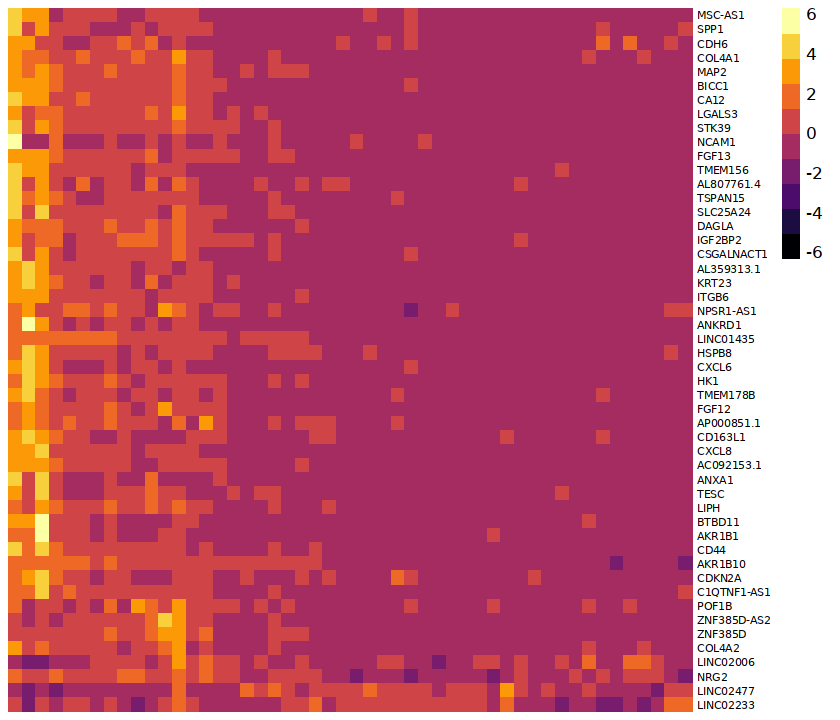

In [204]:
de.top.genes <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()


mat.de <- adata_bin$RNA$data[de.top.genes,]
max_indices.de <- max.col(mat.de)
permutation_vector.de <- order(max_indices.de)
smat.de <- mat.de[permutation_vector.de, ]

options(repr.plot.height=6)
smat.de %>% #[1:sum(max_indices.de == 1),]
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 6,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

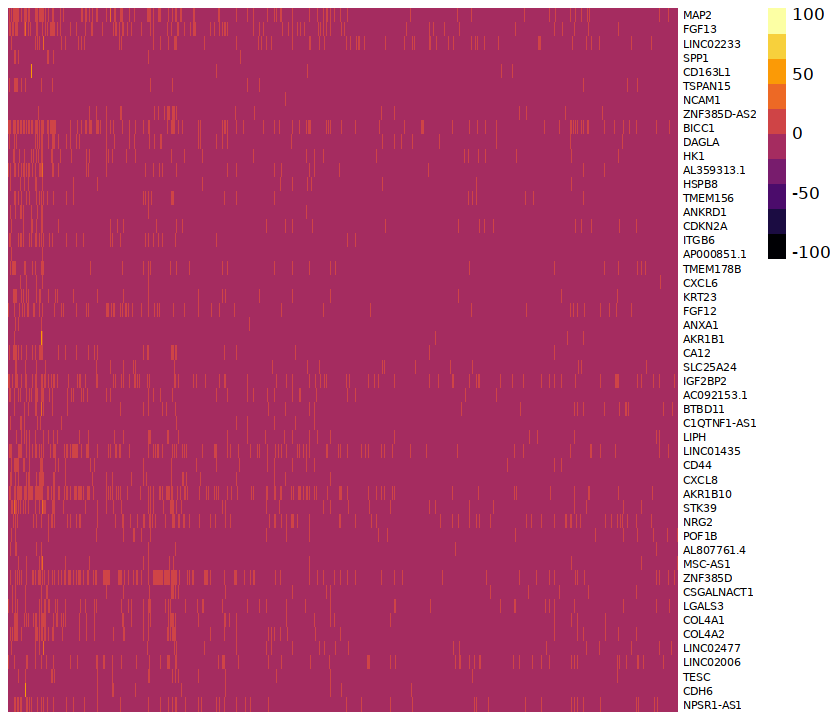

In [209]:
de.top.genes <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()
pseudotime.order <- adata_fib$pseudotime %>% sort() %>% names()

mat.de.bc <- adata_fib$RNA$data[de.top.genes,pseudotime.order]
max_indices.de.bc <- max.col(mat.de.bc)
permutation_vector.de.bc <- order(max_indices.de.bc)
smat.de.bc <- mat.de.bc[permutation_vector.de.bc, ]

options(repr.plot.height=6)
smat.de.bc %>% #[1:sum(max_indices.de.bc == 1),]
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 6,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

In [212]:
adata_fib.norm <- NormalizeData(adata_fib)

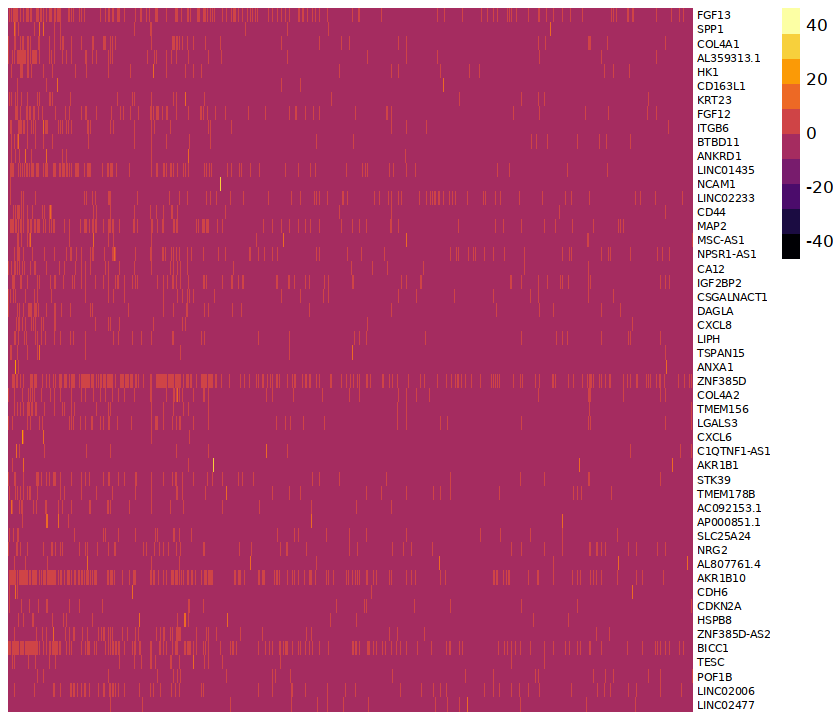

In [213]:
de.top.genes <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()
pseudotime.order <- adata_fib.norm$pseudotime %>% sort() %>% names()

mat.de.bc <- adata_fib.norm$RNA$data[de.top.genes,pseudotime.order]
max_indices.de.bc <- max.col(mat.de.bc)
permutation_vector.de.bc <- order(max_indices.de.bc)
smat.de.bc <- mat.de.bc[permutation_vector.de.bc, ]

options(repr.plot.height=6)
smat.de.bc %>% #[1:sum(max_indices.de.bc == 1),]
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 6,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

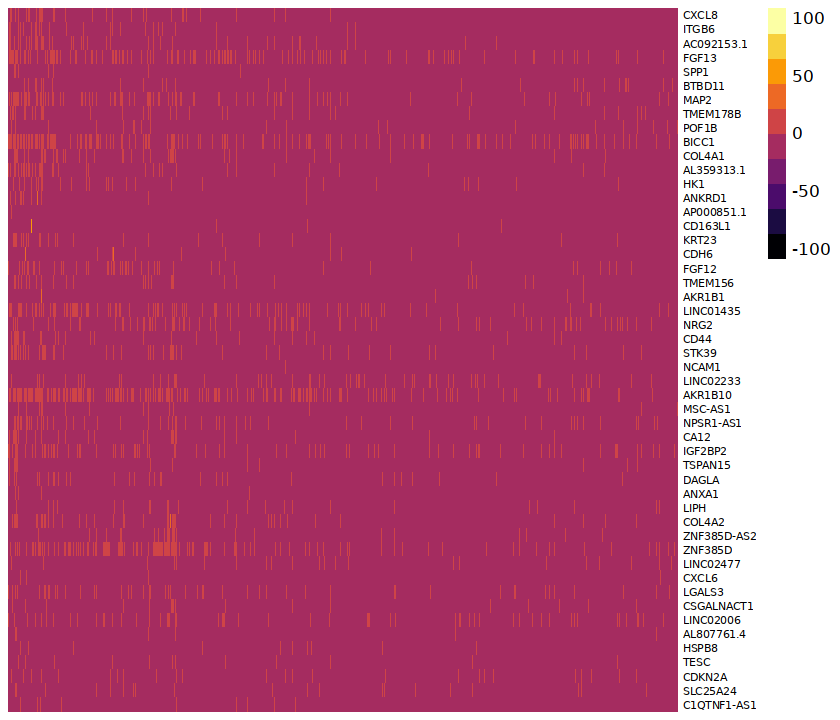

In [216]:
de.top.genes <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()
pseudotime.order <- adata_fib.norm$pseudotime %>% sort() %>% names()

mat.de.bc <- adata_fib.norm$SCT$counts[de.top.genes,pseudotime.order]
max_indices.de.bc <- max.col(mat.de.bc)
permutation_vector.de.bc <- order(max_indices.de.bc)
smat.de.bc <- mat.de.bc[permutation_vector.de.bc, ]

options(repr.plot.height=6)
smat.de.bc %>% #[1:sum(max_indices.de.bc == 1),]
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 6,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

pdf 
  2

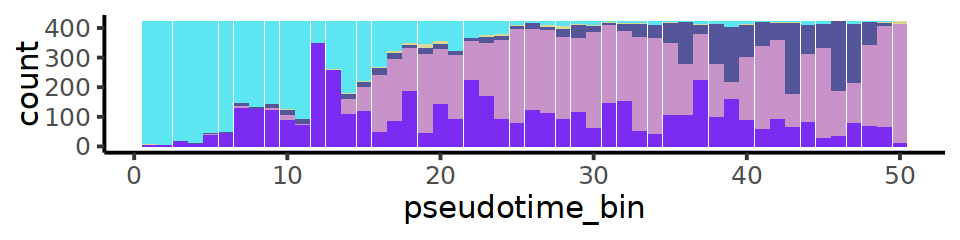

In [223]:
options(repr.plot.height=2, repr.plot.width=8)
p1 <- select(adata_fib[[]], pseudotime_bin, cellsubtype) %>%
    ggplot(aes(x=pseudotime_bin, fill=cellsubtype)) + geom_bar() +
    theme_classic(base_size=18) + scale_fill_manual(values=Hep.colors) +
    theme(legend.position='none')
p1

pdf('/nfs/lab/welison/Liver/Plots/250320_WE_Proportion_Across_Pseudotime.pdf', height=2, width=8)
p1
dev.off()

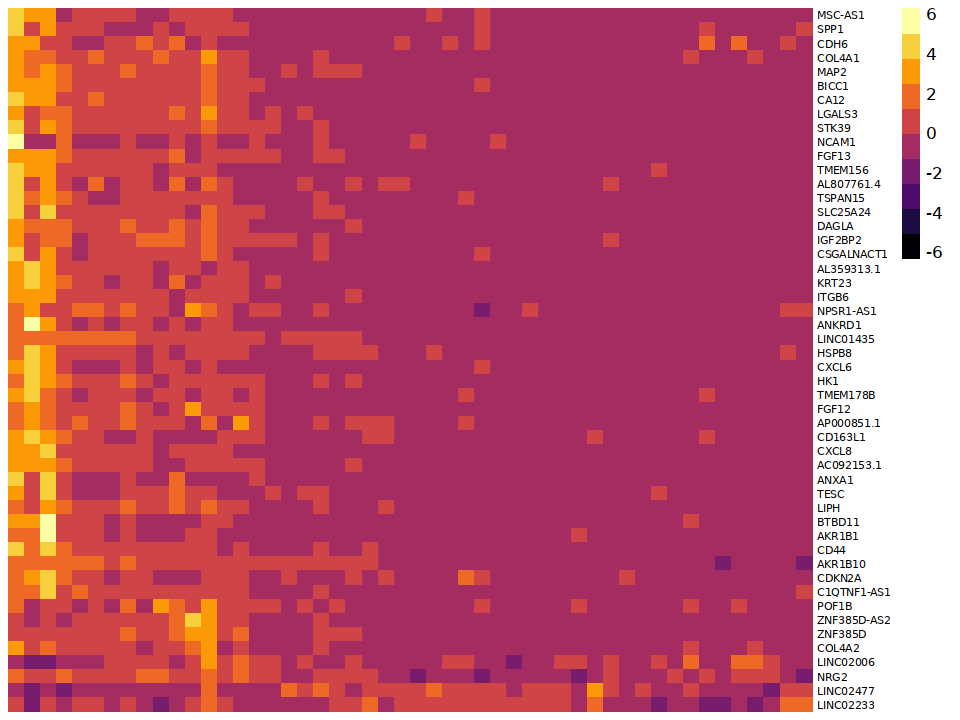

In [221]:
de.top.genes <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/subtypes/01_DESEQ_RNA_Hepatocytes_Subtypes/Hepatocytes.Senescent_High_Fibrosis_vs_Control.dds.res', sep='\t') %>%
    filter(padj < 0.05) %>% arrange(desc(log2FoldChange)) %>% head(n=50) %>% rownames()


mat.de <- adata_bin$RNA$data[de.top.genes,]
max_indices.de <- max.col(mat.de)
permutation_vector.de <- order(max_indices.de)
smat.de <- mat.de[permutation_vector.de, ]

options(repr.plot.height=6)
smat.de %>% #[1:sum(max_indices.de == 1),]
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 6,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA)
options(repr.plot.height=8)

smat.de %>% #[1:sum(max_indices.de == 1),]
    pheatmap(cluster_rows = F, cluster_cols = F, show_colnames = F, scale='row', fontsize_row = 6,
             color=inferno(10), treeheight_row = 0, show_rownames = T, border_color=NA,
            filename='/nfs/lab/welison/Liver/Plots/250320_Pseudotime_50_DE_Heatmap.pdf',
            width=8, height=6)